# Model Definition and Evaluation
## Table of Contents
1. [Model Selection](#model-selection)
2. [Feature Engineering](#feature-engineering)
3. [Hyperparameter Tuning](#hyperparameter-tuning)
4. [Implementation](#implementation)
5. [Evaluation Metrics](#evaluation-metrics)
6. [Comparative Analysis](#comparative-analysis)


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report
# Import models you're considering


## Model Selection
Our oceanographic profiles have two dimensions (depth x size bin), where Biovolume values in neighboring depths and size bins are correlated. This suggests that the 2D pattern of Biovolume is of importance.
By visualizing these 2D patterns as heatmaps, we aim to classify Profiles using convolutional neural networks (CNN). 
- We start by testing a simple CNN and low-resolution heatmaps (with only 45 x 45 pixels)
- We aim to progress towards createing higher-resolution heatmaps with interpolation between data points which we aim to use for transfer learning.

## Feature Engineering

Beyond the baseline preprocessing, our feature engineering focused on preparing the UVP particle-biovolume profiles for convolution-based classification. First, all biovolume values were normalized on a per-profile basis to reduce the influence of varying absolute particle concentrations and highlight relative vertical distribution patterns. Each profile was then reshaped into a structured 40×17 depth–size matrix, effectively forming a 2D heatmap representation. This transformation converts the raw measurements into spatially coherent feature maps suitable for convolutional neural networks. We deliberately refrained from introducing aggregated or hand-crafted features, as CNNs are expected to extract relevant spatial and multiscale patterns directly from the heatmaps.

- adding labels
- adding squared transformation

### Defining Functions

In [3]:
# TODO  :   Function Declaration Cell

import matplotlib.pyplot as plt
import os
import numpy as np
from pathlib import Path
from scipy.ndimage import gaussian_filter
from matplotlib.colors import PowerNorm, LogNorm

heatmap_data = []

## --------------------------------------------------------- ##

def pad_heatmap(
    arr: np.ndarray,
    pad_top: int = 4,
    pad_bottom: int = 4,
    pad_left: int = 1,
    pad_right: int = 1,
    value: float = 0.0,
) -> np.ndarray:
    """
    Pad ein 2D-Array (Heatmap) mit Konstanten (default: 0).

    arr:       2D-Array (H, W)
    pad_top:   zusätzliche Zeilen oben
    pad_bottom:zusätzliche Zeilen unten
    pad_left:  zusätzliche Spalten links
    pad_right: zusätzliche Spalten rechts
    value:     Füllwert (Standard: 0.0)
    """
    return np.pad(
        arr,
        pad_width=((pad_top, pad_bottom), (pad_left, pad_right)),
        mode="constant",
        constant_values=value,
    )

## --------------------------------------------------------- ##

def crop_figure(fig, trim_px=0):
    """
    Converts a Matplotlib Figure into an RGB NumPy array and crops pixels
    at all edges. Compatible with Matplotlib 3.8+.
    """
    fig.canvas.draw()
    # Try new API first (Matplotlib 3.8+)
    try:
        buf = fig.canvas.buffer_rgba()
        img = np.asarray(buf)
        # buffer_rgba() liefert ARGB → zu RGB konvertieren
        img = img[..., :3]  
    except AttributeError:
        # Fallback: ältere Matplotlib-Versionen
        w, h = fig.canvas.get_width_height()
        buf = fig.canvas.tostring_rgb()
        img = np.frombuffer(buf, dtype=np.uint8).reshape((h, w, 3))

    if trim_px != 0:
        # Pixel abschneiden
        return img[trim_px:-trim_px, trim_px:-trim_px, :]
    else:
        return img

## --------------------------------------------------------- ##

# save_all_profiles(df, size_cols[:-3], pixels=45, trim_px=0, max_profiles=15, padding=[2,2,1,3], mp="inferno", intrpl="bilinear", gamma=1, sig=0.1)
def create_profile_heatmap(df, profile_id, size_cols, out_dir, pixels=144, trim_px=0, padding=[0,0,0,0], mp=None, intrpl=None, gam=1, sig=0.1):
    """
    Save a square heatmap for a single profile as a PNG file.
    Only the heatmap is saved — no axes, labels, or surrounding whitespace.
    Now includes pixel-exact border cropping.
    """

    # 1. Profil auswählen
    prof = df[df["Profile_id"] == profile_id].copy()
    if prof.empty:
        return

    # 2. Nach Tiefe sortieren
    prof = prof.sort_values("depth_bin")

    # 3. Heatmap-Matrix generieren (z.B. 40×14 → gepaddet)
    heatmap_data = pad_heatmap(prof[size_cols].to_numpy(), pad_top=padding[0], pad_bottom=padding[1], pad_left=padding[2], pad_right=padding[3])

    # 4. Eine quadratische Figure erzeugen
    fig = plt.figure(figsize=(1, 1), dpi=pixels)
    ax = fig.add_axes([0, 0, 1, 1])   # axes füllt alles

    # 5. Heatmap plotten
    heatmap_smooth = gaussian_filter(heatmap_data, sigma=sig)

    if intrpl == None:
        intrpl = "nearest"
    else:
        intrpl=intrpl

    ax.imshow(
        heatmap_smooth,
        cmap=mp,                          # 'gray' 'inferno' 'turbo' 'magma'
        origin="upper",
        aspect="auto",
        interpolation=intrpl,               # 'nearest' 'bilinear' 'bicubic' 'lanczos' 'spline16' 'spline36'
        # vmin=np.percentile(heatmap_data, 2),
        # vmax=np.percentile(heatmap_data, 99),
        # norm=LogNorm(),
        norm=PowerNorm(gamma=gam),
    )
    
    # alles ausblenden
    ax.axis("off")

    # 6. In Array rendern → Pixel exakt abschneiden
    cropped = crop_figure(fig, trim_px=trim_px)

    plt.close(fig)  # Original-Figure schließen

    # 7. Ordner anlegen
    os.makedirs(out_dir, exist_ok=True)

    # 8. Output-Dateinamen
    safe_id = str(profile_id)
    for ch in ['/', '\\', ':', ';', ' ']:
        safe_id = safe_id.replace(ch, '_')

    filepath = os.path.join(out_dir, f"{safe_id}.png")

    # 9. Als PNG speichern
    import imageio
    imageio.imwrite(filepath, cropped)


## --------------------------------------------------------- ##

# save_all_profiles(df, size_cols[:-3], pixels=45, trim_px=0, max_profiles=15, padding=[2,2,1,3], mp="inferno", intrpl="bilinear", gamma=1, sig=0.1)
def save_all_profiles(df, size_cols, out_dir="../Data/heatmaps", pixels=144, trim_px=0, max_profiles=None, padding=None, mp=None, intrpl=None, gamma=1, sig=0.1):
    """
    Ruft create_profile_heatmap() für viele Profile auf.
    - max_profiles = None  → alle Profile
    - max_profiles = 10    → nur die ersten 10 Profile
    """
    os.makedirs(out_dir, exist_ok=True)

    profile_ids = df["Profile_id"].unique()

    # Wenn max_profiles gesetzt ist, nur die ersten N
    if max_profiles is not None:
        profile_ids = profile_ids[:max_profiles]

    for pid in profile_ids:
        create_profile_heatmap(df, pid, size_cols, out_dir, pixels=pixels, trim_px=trim_px, padding=padding, mp=mp, intrpl=intrpl, gam=gamma, sig=sig)
    
        
    out_path = Path(out_dir).resolve()
    p = out_path.name
    out_path = out_path / f"__params_for_{p}.txt"

    with open(out_path, "w", encoding="utf-8") as f:
        print(f"size: {pixels}^2 px", file=f)
        print(f"crop: {trim_px}px", file=f)
        print(f"color theme: {mp}", file=f)
        print(f"interpolation: {intrpl}", file=f)
        print(f"gamma: {gamma}", file=f)
        print(f"gaussion strength: {sig}", file=f)

## --------------------------------------------------------- ##

def normalize_by_profile_global_max(df, group_col, columns):
    """
    Normalisiert die angegebenen Spalten so, dass:
    - pro Gruppe (group_col, z.B. 'Profile-ID') genau EIN globales Maximum
      über alle angegebenen Spalten und alle Zeilen gesucht wird
    - alle Werte der Gruppe durch dieses globale Maximum geteilt werden
    - 0 bleibt 0
    """

    # 1. Relevante Spalten extrahieren
    sub = df[columns]

    # 2. Pro Gruppe (Profile) das Spaltenmaximum bestimmen
    #    → ergibt für jede Zeile einer Gruppe dieselben Spaltenmaxima
    group_col_max = df.groupby(group_col)[columns].transform("max")

    # 3. Aus diesen Spaltenmaxima das globale Maximum pro Gruppe ableiten
    #    → für jede Zeile einer Gruppe derselbe Skalar
    profile_max = group_col_max.max(axis=1)

    # 4. Division durch 0 vermeiden (Profil komplett 0)
    denom = profile_max.replace(0, 1)

    # 5. Alles durch diesen Skalar teilen
    normalized = sub.div(denom, axis=0)

    # 6. Zurück ins Original-DataFrame schreiben
    df_norm = df.copy()
    df_norm[columns] = normalized

    return df_norm

### Loading Dataset for Plotting Heatmpas

This plot shows all 40 depth bins over 14 instead of 17 size classes of bio volume,
hence the baselinemodel evaluated those classes 15-17 as insignificant.
Each square represents a real datapoint.

*****

WE WILL HAVE TO DISTORED THIS PLOT INTO A SQUARE IMAGE WITHOUT LOSING DATA OR ROUNDING ERRORS.
A 3:1 RATIO BETWEEN 'DEPTH BINS' AND 'SIZE CLASSES SHOULD DELIVER SUFFICIENT SQUARITY,
WHILE 'ZERO'-PADDING ROWS AND COLUMNS TO REACH A PIXELPERFECT RESULT.


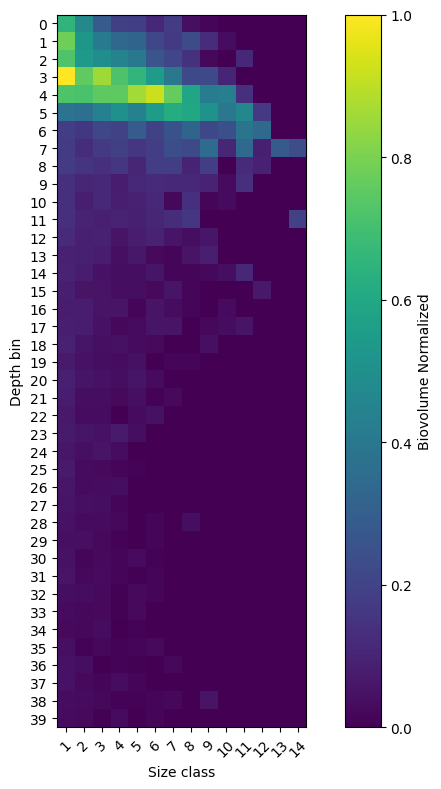

This is a sample of a padded Bioprofile, the way it gets put into the plot function.
⬇︎ This particular padding is static and only an example. ⬇︎


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
3,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
4,0.0,0.653745,0.470178,0.287066,0.188709,0.185985,0.113002,0.179574,0.041313,0.017411,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
5,0.0,0.780362,0.530190,0.415375,0.334251,0.323694,0.213776,0.168894,0.228241,0.126525,0.034254,0.000000,0.000000,0.000000,0.000000,0.0
6,0.0,0.725989,0.536002,0.490964,0.447350,0.403615,0.263119,0.212265,0.147485,0.022054,0.000000,0.112848,0.000000,0.000000,0.000000,0.0
7,0.0,1.000000,0.755412,0.859124,0.719881,0.659883,0.553178,0.400242,0.219777,0.220892,0.103590,0.000000,0.000000,0.000000,0.000000,0.0
8,0.0,0.724283,0.711253,0.750594,0.750754,0.860820,0.921165,0.763016,0.591890,0.425577,0.428972,0.139844,0.000000,0.000000,0.000000,0.0
9,0.0,0.379674,0.364668,0.437849,0.500825,0.439851,0.548332,0.618897,0.596689,0.508930,0.395237,0.467939,0.164274,0.000000,0.000000,0.0


In [4]:
# TODO  :   Load the dataset
# Replace 'your_dataset.csv' with the path to your actual dataset

df = pd.read_pickle('../Data/Biovolume_per_size_class_and_depth_updated.pkl')

# Perform any feature engineering steps
# Example: df['new_feature'] = df['feature1'] + df['feature2']

import matplotlib.pyplot as plt
import numpy as np

# 1. Biovolume-Spalten auswählen
size_cols = [col for col in df.columns if col.startswith("Biovolume ")]
# Remove three of the largest size bins
size_cols = size_cols[:-3]

# Normalisierung – kann man machen wird grafisch aber schon automatisch vom plot erledigt
df = normalize_by_profile_global_max(df, "Profile_id", size_cols)
# display(df.head(40))

# 2. Ein Profil auswählen
pid = "0000a_WMO5906623_recovery_profiles"   # hier deine echte Profile_id einsetzen
df_prof = df[df["Profile_id"] == pid].copy()

# 3. Nach Tiefe sortieren (wichtig für "saubere" y-Achse)
df_prof = df_prof.sort_values("depth_bin")

# 4. 2D-Array für die Heatmap bauen: (n_depth_bins x n_size_classes)
heatmap_data = df_prof[size_cols].to_numpy()  # Shape ~ (40, 17)

# 5. Plotten
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(
    heatmap_data,
    aspect="equal",      # oder "equal" wenn du willst
    origin="upper"      # Tiefen von unten nach oben
)

# Achsen-Beschriftungen
ax.set_xlabel("Size class")
ax.set_ylabel("Depth bin")

# Optional: Ticks mit Spaltennamen
ax.set_xticks(np.arange(len(size_cols)))
ax.set_xticklabels(range(1, len(size_cols)+1), rotation=45)

ax.set_yticks(np.arange(len(df_prof["depth_bin"].unique())))
ax.set_yticklabels(sorted(df_prof["depth_bin"].unique()))

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Biovolume Normalized")

plt.tight_layout()

print(f"="*100)
print("This plot shows all 40 depth bins over 14 instead of 17 size classes of bio volume,\nhence the baselinemodel evaluated those classes 15-17 as insignificant.\nEach square represents a real datapoint.")
print("\n"+f"*"*5+"\n")
print("WE WILL HAVE TO DISTORED THIS PLOT INTO A SQUARE IMAGE WITHOUT LOSING DATA OR ROUNDING ERRORS.")
print("A 3:1 RATIO BETWEEN 'DEPTH BINS' AND 'SIZE CLASSES SHOULD DELIVER SUFFICIENT SQUARITY,\nWHILE 'ZERO'-PADDING ROWS AND COLUMNS TO REACH A PIXELPERFECT RESULT.")
print(f"="*100)

plt.show()

print(f"="*100)
print("This is a sample of a padded Bioprofile, the way it gets put into the plot function.\n⬇︎ This particular padding is static and only an example. ⬇︎")
print(f"="*100)
pd.DataFrame(pad_heatmap(heatmap_data))

### Creating Heatmap Plots and Saving them to Files 

In [ ]:
# TODO  :   Converting our input features into heatmaps and export them as an image dataset.

# Normalizing the size columns.
size_cols = [col for col in df.columns if col.startswith("Biovolume ")]
df = normalize_by_profile_global_max(df, "Profile_id", size_cols)

"""
This first part is for redundancy only.
It has been done in a differnet cell before but doesn't always travel.
So we keep it here for 'ease of use'.
"""

## --------------------------------------------------------- ##

# Creating and storing the feature-heatmaps in a directory of your choice (default: '/Data/heatmaps').
# save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples", pixels=240, trim_px=2, max_profiles=15, sig=0.1)

# save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_00", pixels=45, trim_px=0, max_profiles=3, padding=[2,3,1,0])
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_samples", pixels=45, trim_px=0, max_profiles=3, padding=[2,3,1,0])
# save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_01", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1])
# save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_02", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], intrpl="bilinear")
# save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_03", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], intrpl="bicubic")

# save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_10", pixels=45, trim_px=0, max_profiles=3, padding=[2,3,1,0], mp="gray")
# save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_11", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="gray")
# save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_12", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="gray", intrpl="bilinear")
# save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_13", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="gray", intrpl="bicubic")

# save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_20", pixels=45, trim_px=0, max_profiles=3, padding=[2,3,1,0], mp="inferno")
# save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_21", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="inferno")
# save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_22", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="inferno", intrpl="bilinear")
# save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_23", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="inferno", intrpl="bicubic")

# save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_30", pixels=45, trim_px=0, max_profiles=3, padding=[2,3,1,0], mp="turbo")
# save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_31", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="turbo")
# save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_32", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="turbo", intrpl="bilinear")
# save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_33", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="turbo", intrpl="bicubic")

"""
Here you are able to create the heatmap image output.
    pixels = [48, 144, 240] – are good choices and multiples of 16 (Columns/ Features)
            → 0·1·1·1·1·1·1·1·1·1·1·1·1·1·1·0 (one column padding on either side)

    - df: your dataframe
    - size_cols: how many biovolume size columns should be accounted for
    - out_dir: pick your output dir, this is more for putting out sample data so you don't overwrite your main dataset.
    - pixels: image square size
    - trim_px: cropping image by removing pixels along each side of the square → here you choose how many (by default there is always one line of pixels removed)
    - max_profiles: also more for test purposes
    - sig: sigma parameter of the gaussian filter of the cubic interpolation function

The full ⬇︎ image set creator uses a 240px square with 1px trim resulting in a 238px square heatmap.
The output you find in your '/Data/heatmaps/' directory. 
"""

# TODO : Uncomment for final outpput!! ⬇︎

# save_all_profiles(df, size_cols[:-3])                             # save all profile heatmaps
# save_all_profiles(df, size_cols[:-3], pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], mp="turbo", intrpl="bicubic")
# save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_03", pixels=48, trim_px=1, max_profiles=15, padding=[4,4,1,1], mp="inferno", intrpl="bilinear", gamma=1, sig=0.1)

# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_00", pixels=45, trim_px=0, padding=[2,3,1,0])
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_10", pixels=45, trim_px=0, padding=[2,3,1,0], mp="gray")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_20", pixels=45, trim_px=0, padding=[2,3,1,0], mp="inferno")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_30", pixels=45, trim_px=0, padding=[2,3,1,0], mp="turbo")

# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_01", pixels=48, trim_px=1, padding=[4,4,1,1])
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_02", pixels=48, trim_px=1, padding=[4,4,1,1], intrpl="bilinear")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_03", pixels=48, trim_px=1, padding=[4,4,1,1], intrpl="bicubic")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_04", pixels=96, trim_px=4, padding=[4,4,1,1], intrpl="bilinear")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_05", pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], intrpl="bilinear", gamma=0.8)
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_06", pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], intrpl="bilinear", gamma=0.6)
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_07", pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], intrpl="bilinear", gamma=0.4)
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_25", pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], mp="inferno", intrpl="bilinear", gamma=0.8)
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_26", pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], mp="inferno", intrpl="bilinear", gamma=0.6)
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_27", pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], mp="inferno", intrpl="bilinear", gamma=0.4)
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_06", pixels=144, trim_px=12, padding=[4,4,1,1], intrpl="bilinear")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_07", pixels=192, trim_px=16, padding=[4,4,1,1], intrpl="bilinear")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_34", pixels=48, trim_px=1, padding=[4,4,1,1], mp="turbo", intrpl="bilinear")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_35", pixels=48, trim_px=1, padding=[4,4,1,1], mp="turbo", intrpl="bicubic")

# hmp_params = []
# out_dir = [f"../Data/heatmaps_{n+1}"]
# pixels = [45, 48, 96, 144, 192, 240]
# pixels = [0, 1, 4, 12, 16, 20]

## First CNN: small heatmaps
-  workflow with small heatmaps & geographical & clster-stratified split

In [6]:
# install if necessary:
#pip install imbalanced-learn pillow

In [13]:
## install if necessary:
#pip install imbalanced-learn pillow

import numpy as np
import pandas as pd
import pickle
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GaussianNoise
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from PIL import Image
import warnings
warnings.filterwarnings('ignore')


# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Path attributes

DATA_DIR = Path("../Data")
HEATMAP_DIR = DATA_DIR / "heatmaps_05"

### Functions for: data & heatmap loading, train/test splitting, balancing training data & scaling heatmap pixels

In [14]:

######################## initialize a class with attributes = data directories and files ###############################
# add every new function to this class

class HeatmapCNNClassifier:
    def __init__(self, data_dir=DATA_DIR, heatmap_dir=HEATMAP_DIR):
            self.data_dir = Path(data_dir)
            self.heatmap_dir = Path(heatmap_dir)
            self.train_test_file = self.data_dir / "Profile_id_to_train_test_cross_val_v2.pkl"
            self.clusters_file = self.data_dir / "Profile_id_to_clusters_v3.pkl"
            self.scaler = StandardScaler()
            self.label_encoder = LabelEncoder()
        
######################## Load data assignments ###############################

def load_data_assignments(self):
    """Load data assignments from pickle files"""
    print("Loading data assignments...")
    
    # Load train/test and cross-validation assignments (DataFrame)
    with open(self.train_test_file, 'rb') as f:
        train_test_df = pickle.load(f)
    
    # Load cluster assignments (DataFrame)
    with open(self.clusters_file, 'rb') as f:
        clusters_df = pickle.load(f)
    
    print(f"Train/test DataFrame shape: {train_test_df.shape}")
    print(f"Clusters DataFrame shape: {clusters_df.shape}")
    print(f"Train/test columns: {train_test_df.columns.tolist()}")
    print(f"Clusters columns:  {clusters_df.columns.tolist()}")
    
    # Convert DataFrames to dictionaries for easier lookup
    # Assuming Profile_id is the key column
    self.train_test_cv = {}
    for _, row in train_test_df.iterrows():
        profile_id = row['Profile_id']
        # Create dictionary with remaining columns
        self.train_test_cv[profile_id] = {col: row[col] for col in train_test_df.columns if col != 'Profile_id'}
    
    self.clusters = {}
    for _, row in clusters_df.iterrows():
        profile_id = row['Profile_id']
        # Assuming there's a cluster column - let's find it
        cluster_cols = [col for col in clusters_df.columns if col != 'Profile_id']
        if len(cluster_cols) == 1:
            self.clusters[profile_id] = row[cluster_cols[0]]
        else:
            # If multiple columns, store as dictionary
            self.clusters[profile_id] = {col: row[col] for col in cluster_cols}
    
    print(f"Loaded assignments for {len(self.train_test_cv)} profiles")
    print(f"Loaded cluster assignments for {len(self.clusters)} profiles")
    
    # Show sample data structure
    sample_profile = list(self.train_test_cv.keys())[0]
    print(f"Sample train/test data for profile {sample_profile}:  {self.train_test_cv[sample_profile]}")
    print(f"Sample cluster data for profile {sample_profile}:  {self.clusters[sample_profile]}")

# add the function to the class
HeatmapCNNClassifier.load_data_assignments = load_data_assignments

######################## Load heatmaps ###############################

def load_heatmaps(self):
    """Load heatmap images and create feature matrices"""
    print("Loading heatmap images...")
    
    # Get list of available heatmap files
    heatmap_files = list(self.heatmap_dir.glob("*.png"))
    print(f"Found {len(heatmap_files)} PNG files in {self.heatmap_dir}")
    
    if len(heatmap_files) == 0:
        raise FileNotFoundError(f"No PNG files found in {self.heatmap_dir}")
    
    # Extract profile IDs from filenames (remove .png extension)
    available_profile_ids = [f.stem for f in heatmap_files]
    
    # Debug: Show sample filenames and extracted profile IDs
    sample_files = heatmap_files[:5]
    sample_ids = [f.stem for f in sample_files]
    print(f"Sample filenames: {[f.name for f in sample_files]}")
    print(f"Sample extracted profile IDs: {sample_ids}")
    
    # Convert profile IDs to consistent format (strings)
    train_test_ids = set(str(k) for k in self.train_test_cv.keys())
    cluster_ids = set(str(k) for k in self.clusters.keys())
    filename_ids = set(str(id_) for id_ in available_profile_ids)
    
    print(f"Available profile IDs from filenames: {len(filename_ids)}")
    print(f"Profile IDs with train/test data: {len(train_test_ids)}")
    print(f"Profile IDs with cluster data:  {len(cluster_ids)}")
    
    # Find common profile IDs across all data sources
    common_with_train_test = filename_ids & train_test_ids
    common_with_clusters = filename_ids & cluster_ids
    common_all = filename_ids & train_test_ids & cluster_ids
    
    print(f"Files matching train/test IDs: {len(common_with_train_test)}")
    print(f"Files matching cluster IDs: {len(common_with_clusters)}")
    print(f"Files matching all data sources: {len(common_all)}")
    
    if len(common_all) == 0:
        print("\nDEBUGGING: No matching profile IDs found!")
        print("Sample IDs from each source:")
        print(f"Filenames: {list(filename_ids)[:5]}")
        print(f"Train/test:  {list(train_test_ids)[:5]}")
        print(f"Clusters: {list(cluster_ids)[:5]}")
        raise ValueError("No matching profile IDs found between files and metadata")
    
    common_ids = list(common_all)
    print(f"Found {len(common_ids)} profiles with complete data")
    
    # Load images and extract data
    X_data = []
    y_data = []
    profile_ids = []
    data_types = []
    cv_folds = []
    
    # Load a sample image to get dimensions
    sample_profile_id = common_ids[0]
    sample_img_path = self.heatmap_dir / f"{sample_profile_id}.png"
    sample_img = Image.open(sample_img_path)
    sample_array = np.array(sample_img)
    img_shape = sample_array.shape
    print(f"Image dimensions: {img_shape}")
    
    for profile_id_str in common_ids:
        # Convert string back to original type for dictionary lookup
        # Try both string and original type
        lookup_id = profile_id_str
        for original_id in self.train_test_cv.keys():
            if str(original_id) == profile_id_str:
                lookup_id = original_id
                break
        
        # Load image
        img_path = self.heatmap_dir / f"{profile_id_str}.png"
        img = Image.open(img_path)
        img_array = np.array(img)
        
        # Normalize pixel values to [0, 1]
        if img_array.dtype == np.uint8:
            img_array = img_array.astype(np.float32) / 255.0
        
        X_data.append(img_array)
        
        # Extract cluster assignment
        cluster_data = self.clusters[lookup_id]
        if isinstance(cluster_data, dict):
            # If cluster data is a dictionary, assume first value is the cluster
            y_data.append(list(cluster_data.values())[0])
        else:
            y_data.append(cluster_data)
        
        profile_ids.append(profile_id_str)
        data_types.append(self.train_test_cv[lookup_id]['data_type'])
        cv_folds.append(self.train_test_cv[lookup_id]['CV_fold'])
    
    self.X_data = np.array(X_data)
    self.y_data = np.array(y_data)
    self.profile_ids = np.array(profile_ids)
    self.data_types = np.array(data_types)
    self.cv_folds = np.array(cv_folds)
    
    print(f"Loaded {len(self.X_data)} heatmaps with shape {self.X_data.shape}")
    print(f"Unique clusters found: {np.unique(self.y_data)}")
    print(f"Data types found: {np.unique(self.data_types)}")
    print(f"CV folds found: {np.unique(self.cv_folds)}")

# add the function to the class
HeatmapCNNClassifier.load_heatmaps = load_heatmaps


######################## Train/test split ###############################

def split_train_test(self):
    """Split data into train and test sets based on pre-defined assignments"""
    print("Splitting data into train and test sets...")
    
    train_mask = self.data_types == 'train'
    test_mask = self.data_types == 'test'
    
    self.X_train = self.X_data[train_mask]
    self.y_train = self.y_data[train_mask]
    self.train_profile_ids = self.profile_ids[train_mask]
    self.train_cv_folds = self.cv_folds[train_mask]
    
    self.X_test = self.X_data[test_mask]
    self.y_test = self.y_data[test_mask]
    self.test_profile_ids = self.profile_ids[test_mask]
    
    print(f"Training set:  {len(self.X_train)} samples")
    print(f"Test set: {len(self.X_test)} samples")
    
    # Encode labels
    self.y_train_encoded = self.label_encoder.fit_transform(self.y_train)
    self.y_test_encoded = self.label_encoder.transform(self.y_test)
    self.n_classes = len(self.label_encoder.classes_)
    
    print(f"Number of classes: {self.n_classes}")
    print(f"Classes: {self.label_encoder.classes_}")

# add the function to the class
HeatmapCNNClassifier.split_train_test = split_train_test


######################## Balance classes per fold - SMOTE Tomek link ###############################

def balance_classes_per_fold_SMOTETomek(self):
    """Apply balancing within each CV fold separately"""
    print("Balancing classes per fold using SMOTETomek (SMOTE + Tomek links)...")
    
    unique_folds = np.unique(self.train_cv_folds)
    print(f"Processing {len(unique_folds)} folds:  {unique_folds}")
    
    # Store balanced data for each fold
    self.fold_balanced_data = {}
    
    for fold in unique_folds:
        print(f"\nBalancing fold:  {fold}")
        
        # Get training data for this fold (all other folds)
        val_mask = self.train_cv_folds == fold
        train_mask = ~val_mask
        
        X_train_fold = self.X_train[train_mask]
        y_train_fold = self.y_train_encoded[train_mask]
        
        print(f"Original fold {fold} training size: {len(X_train_fold)}")
        
        # Check if balancing is needed for this fold
        fold_counts = Counter(y_train_fold)
        min_count = min(fold_counts.values())
        max_count = max(fold_counts.values())
        
        if max_count / min_count > 1.5:  # Apply balancing if imbalanced
            # Reshape data for resampling (flatten images)
            X_train_fold_flat = X_train_fold.reshape(len(X_train_fold), -1)
            
            # Apply SMOTETomek
            smote_tomek = SMOTETomek(
                smote=SMOTE(random_state=42, k_neighbors=min(3, min_count-1)),
                tomek=TomekLinks(),
                random_state=42
            )
            
            X_train_balanced, y_train_balanced = smote_tomek.fit_resample(X_train_fold_flat, y_train_fold)
            
            # Reshape back to image format
            X_train_balanced = X_train_balanced.reshape((-1,) + X_train_fold.shape[1:])
            
            print(f"Balanced fold {fold} training size: {len(X_train_balanced)}")
            
            # Show distribution after balancing
            balanced_counts = Counter(y_train_balanced)
            for cluster_idx, count in sorted(balanced_counts.items()):
                cluster_name = self.label_encoder.classes_[cluster_idx]
                print(f"  Cluster {cluster_name}: {count} samples")
                
        else:
            print(f"Fold {fold} is already balanced, no resampling needed")
            X_train_balanced = X_train_fold
            y_train_balanced = y_train_fold
        
        # Store balanced data for this fold
        self.fold_balanced_data[fold] = {
            'X_train': X_train_balanced,
            'y_train': y_train_balanced,
            'X_val': self.X_train[val_mask],
            'y_val': self.y_train_encoded[val_mask]
        }

# add the function to the class
HeatmapCNNClassifier.balance_classes_per_fold_SMOTETomek = balance_classes_per_fold_SMOTETomek


######################## Balance classes per fold - Oversampling and undersampling ###############################

def balance_classes_per_fold_simple(self):
    """Apply simple over/undersampling to mean cluster size within each CV fold"""
    print("Balancing classes per fold using simple over/undersampling to mean...")
    
    unique_folds = np.unique(self.train_cv_folds)
    print(f"Processing {len(unique_folds)} folds: {unique_folds}")
    
    # Store balanced data for each fold
    self.fold_balanced_data = {}
    
    for fold in unique_folds: 
        print(f"\nBalancing fold: {fold}")
        
        # Get training data for this fold (all other folds)
        val_mask = self.train_cv_folds == fold
        train_mask = ~val_mask
        
        X_train_fold = self.X_train[train_mask]
        y_train_fold = self.y_train_encoded[train_mask]
        
        print(f"Original fold {fold} training size: {len(X_train_fold)}")
        
        # Calculate cluster distribution
        fold_counts = Counter(y_train_fold)
        total_samples = len(y_train_fold)
        n_clusters = len(fold_counts)
        target_per_cluster = total_samples // n_clusters  # Mean number per cluster
        
        print(f"Target samples per cluster: {target_per_cluster}")
        print("Original distribution:", dict(fold_counts))
        
        # Check if balancing is needed
        min_count = min(fold_counts.values())
        max_count = max(fold_counts.values())
        
        if max_count / min_count > 1.5:  # Apply balancing if imbalanced
            X_balanced_list = []
            y_balanced_list = []
            
            for cluster_idx in sorted(fold_counts.keys()):
                # Get all samples for this cluster
                cluster_mask = y_train_fold == cluster_idx
                X_cluster = X_train_fold[cluster_mask]
                y_cluster = y_train_fold[cluster_mask]
                
                current_count = len(X_cluster)
                cluster_name = self.label_encoder.classes_[cluster_idx]
                
                if current_count < target_per_cluster:
                    # OVERSAMPLE:  randomly duplicate samples to reach target
                    n_to_add = target_per_cluster - current_count
                    print(f"  Oversampling Cluster {cluster_name}:  {current_count} -> {target_per_cluster} (+{n_to_add})")
                    
                    # Randomly sample with replacement
                    oversample_indices = np.random.choice(len(X_cluster), 
                                                        size=n_to_add, 
                                                        replace=True)
                    X_oversampled = X_cluster[oversample_indices]
                    y_oversampled = y_cluster[oversample_indices]
                    
                    # Combine original + oversampled
                    X_cluster_balanced = np.vstack([X_cluster, X_oversampled])
                    y_cluster_balanced = np.concatenate([y_cluster, y_oversampled])
                    
                elif current_count > target_per_cluster:
                    # UNDERSAMPLE: randomly select subset to reach target
                    print(f"  Undersampling Cluster {cluster_name}: {current_count} -> {target_per_cluster} (-{current_count - target_per_cluster})")
                    
                    # Randomly sample without replacement
                    undersample_indices = np.random.choice(len(X_cluster), 
                                                        size=target_per_cluster, 
                                                        replace=False)
                    X_cluster_balanced = X_cluster[undersample_indices]
                    y_cluster_balanced = y_cluster[undersample_indices]
                    
                else:
                    # Already at target size
                    print(f"  Cluster {cluster_name}:  {current_count} (no change needed)")
                    X_cluster_balanced = X_cluster
                    y_cluster_balanced = y_cluster
                
                X_balanced_list.append(X_cluster_balanced)
                y_balanced_list.append(y_cluster_balanced)
            
            # Combine all balanced clusters
            X_train_balanced = np.vstack(X_balanced_list)
            y_train_balanced = np.concatenate(y_balanced_list)
            
            # Shuffle the balanced data
            shuffle_indices = np.random.permutation(len(X_train_balanced))
            X_train_balanced = X_train_balanced[shuffle_indices]
            y_train_balanced = y_train_balanced[shuffle_indices]
            
            print(f"Balanced fold {fold} training size: {len(X_train_balanced)}")
            
            # Show final distribution
            final_counts = Counter(y_train_balanced)
            for cluster_idx, count in sorted(final_counts.items()):
                cluster_name = self.label_encoder.classes_[cluster_idx]
                print(f"  Final Cluster {cluster_name}: {count} samples")
                
        else:
            print(f"Fold {fold} is already balanced, no resampling needed")
            X_train_balanced = X_train_fold
            y_train_balanced = y_train_fold
        
        # Store balanced data for this fold
        self.fold_balanced_data[fold] = {
            'X_train': X_train_balanced,
            'y_train': y_train_balanced,
            'X_val': self.X_train[val_mask],
            'y_val': self.y_train_encoded[val_mask]
        }
        
    print("\nSimple balancing complete!")

# add the function to the class
HeatmapCNNClassifier.balance_classes_per_fold_simple = balance_classes_per_fold_simple


######################## Scale heatmap pixel data ###############################

def scale_data(self):
    """Scale the heatmap pixel data"""
    print("Scaling heatmap pixel data...")
    
    # Scale original training data for test set evaluation
    original_shape = self.X_train.shape
    X_train_flat = self.X_train.reshape(len(self.X_train), -1)
    X_test_flat = self.X_test.reshape(len(self.X_test), -1)
    
    # Fit scaler on original training data
    X_train_scaled = self.scaler.fit_transform(X_train_flat)
    X_test_scaled = self.scaler.transform(X_test_flat)
    
    # Reshape back to image format
    self.X_train_scaled = X_train_scaled.reshape(original_shape)
    self.X_test_scaled = X_test_scaled.reshape(self.X_test.shape)
    
    print(f"Scaled training data shape: {self.X_train_scaled.shape}")
    print(f"Scaled test data shape: {self.X_test_scaled.shape}")
    
    # Scale balanced data for each fold
    if hasattr(self, 'fold_balanced_data'):
        print("Scaling balanced fold data...")
        for fold in self.fold_balanced_data.keys():
            fold_data = self.fold_balanced_data[fold]
            
            # Scale training data for this fold
            X_train_fold_flat = fold_data['X_train'].reshape(len(fold_data['X_train']), -1)
            X_val_fold_flat = fold_data['X_val'].reshape(len(fold_data['X_val']), -1)
            
            # Use same scaler fitted on original training data
            X_train_fold_scaled = self.scaler.transform(X_train_fold_flat)
            X_val_fold_scaled = self.scaler.transform(X_val_fold_flat)
            
            # Reshape back to image format
            self.fold_balanced_data[fold]['X_train_scaled'] = X_train_fold_scaled.reshape((-1,) + fold_data['X_train'].shape[1:])
            self.fold_balanced_data[fold]['X_val_scaled'] = X_val_fold_scaled.reshape((-1,) + fold_data['X_val'].shape[1:])

# add the function to the class
HeatmapCNNClassifier.scale_data = scale_data
    

### Function for data augmentation with Gaussian Noise in 1 x 3 pixel-blocks (like the data points)

Found 5619 PNG heatmap files
Loaded c_son298_1_003.png:  shape (46, 46, 3)
  With block_size=3, this represents 15 datapoints along x-axis
Loaded tara_111_00_j.png:  shape (46, 46, 3)
  With block_size=3, this represents 15 datapoints along x-axis
Loaded sn201_2022_p2_ctd11201.png:  shape (46, 46, 3)
  With block_size=3, this represents 15 datapoints along x-axis
Loaded lohafex_ps73_160.png:  shape (46, 46, 3)
  With block_size=3, this represents 15 datapoints along x-axis


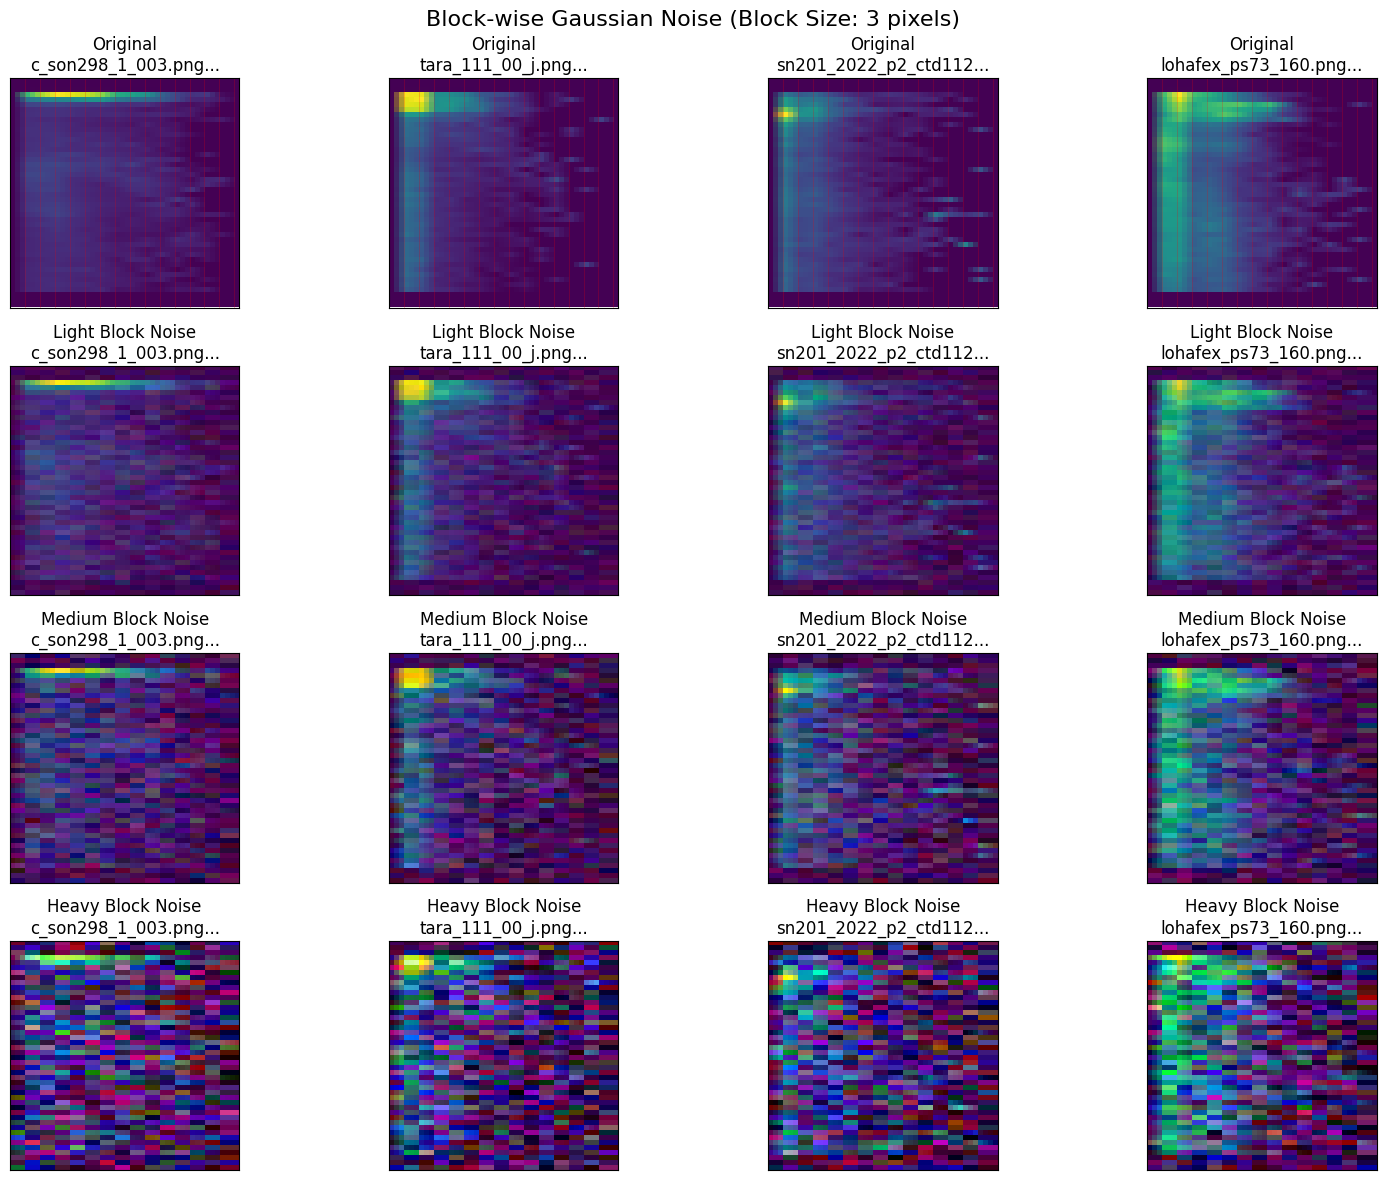


BLOCK-WISE NOISE ANALYSIS
Block size: 3 pixels per datapoint
Number of datapoints along x-axis: 15

Light Block Noise (σ = 0.05):
  Mean absolute difference: 0.0378
  Max absolute difference: 0.1608
  Within-block correlation: 0.996

Medium Block Noise (σ = 0.1):
  Mean absolute difference: 0.0750
  Max absolute difference: 0.3692
  Within-block correlation: 0.998

Heavy Block Noise (σ = 0.2):
  Mean absolute difference: 0.1445
  Max absolute difference: 0.6709
  Within-block correlation: 0.999


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import random
import os
from PIL import Image
import tensorflow as tf

def add_block_gaussian_noise(image, noise_level, block_size=3):
    """
    Add Gaussian noise in blocks of pixels along x-axis
    
    Parameters: 
    image (np.array): Input image 
    noise_level (float): Standard deviation of noise
    block_size (int): Number of pixels per block (default 3)
    """
    if noise_level == 0.0:
        return image
    
    height, width = image.shape[: 2]
    n_channels = image.shape[2] if len(image.shape) == 3 else 1
    
    # Calculate number of complete blocks along x-axis
    n_blocks = width // block_size
    effective_width = n_blocks * block_size
    
    # Create noise at the block level (one noise value per block)
    block_noise_shape = (height, n_blocks) + ((n_channels,) if n_channels > 1 else ())
    block_noise = np.random.normal(0, noise_level, block_noise_shape)
    
    # Expand each noise value to fill the entire block (repeat 3 times along x-axis)
    if n_channels > 1:
        # Multi-channel image
        pixel_noise = np.repeat(block_noise, block_size, axis=1)
        # Handle any remaining pixels if width is not divisible by block_size
        if effective_width < width:
            remaining_pixels = width - effective_width
            last_block_noise = block_noise[: , -1: , : ] 
            last_block_expanded = np.repeat(last_block_noise, remaining_pixels, axis=1)
            pixel_noise = np.concatenate([pixel_noise, last_block_expanded], axis=1)
    else:
        # Grayscale image
        pixel_noise = np.repeat(block_noise, block_size, axis=1)
        if effective_width < width:
            remaining_pixels = width - effective_width
            last_block_noise = block_noise[:, -1:]
            last_block_expanded = np.repeat(last_block_noise, remaining_pixels, axis=1)
            pixel_noise = np.concatenate([pixel_noise, last_block_expanded], axis=1)
    
    # Add noise to image and clip to valid range
    noisy_image = image + pixel_noise
    return np.clip(noisy_image, 0, 1)

def test_block_gaussian_noise(heatmap_dir="../Data/heatmaps", block_size=3):
    """
    Test block-wise Gaussian noise on PNG heatmap files
    """
    # Set random seed for reproducibility
    random.seed(42)
    np.random.seed(42)
    
    # Get random heatmap files
    heatmap_files = [f for f in os.listdir(heatmap_dir) if f.endswith('.png')]
    
    if len(heatmap_files) == 0:
        print(f"No .png files found in {heatmap_dir}")
        return
    
    print(f"Found {len(heatmap_files)} PNG heatmap files")
    selected_files = random.sample(heatmap_files, min(4, len(heatmap_files)))
    
    # Load and prepare heatmaps
    heatmaps = []
    for filename in selected_files:
        img_path = os.path.join(heatmap_dir, filename)
        img = Image.open(img_path)
        heatmap = np.array(img).astype(np.float32) / 255.0
        
        # Handle RGBA by removing alpha channel
        if len(heatmap.shape) == 3 and heatmap.shape[2] == 4:
            heatmap = heatmap[: , :, :3]
        
        print(f"Loaded {filename}:  shape {heatmap.shape}")
        print(f"  With block_size={block_size}, this represents {heatmap.shape[1]//block_size} datapoints along x-axis")
        heatmaps.append(heatmap)
    
    # Define noise levels
    noise_configs = [
        (0.0, "Original"),
        (0.05, "Light Block Noise"),  
        (0.1, "Medium Block Noise"),
        (0.2, "Heavy Block Noise")
    ]
    
    # Create plot
    fig, axes = plt.subplots(4, len(selected_files), figsize=(4*len(selected_files), 12))
    
    # Handle single file case
    if len(selected_files) == 1:
        axes = axes.reshape(-1, 1)
    
    for row, (noise_level, label) in enumerate(noise_configs):
        for col in range(len(selected_files)):
            # Apply block-wise noise
            display_data = add_block_gaussian_noise(heatmaps[col], noise_level, block_size)
            
            # Display the heatmap
            if len(display_data.shape) == 3 and display_data.shape[2] == 3:
                # RGB image
                axes[row, col].imshow(display_data)
            elif len(display_data.shape) == 3:
                # Multi-channel - average for display
                axes[row, col].imshow(np.mean(display_data, axis=-1), cmap='viridis')
            else:
                # Grayscale
                axes[row, col].imshow(display_data, cmap='viridis')
            
            axes[row, col].set_title(f"{label}\n{selected_files[col][:20]}...")
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
            
            # Add grid lines to show block structure (optional)
            if row == 0:  # Only on original images
                width = display_data.shape[1]
                for x in range(0, width, block_size):
                    axes[row, col].axvline(x - 0.5, color='red', alpha=0.3, linewidth=0.5)
    
    plt.suptitle(f'Block-wise Gaussian Noise (Block Size: {block_size} pixels)', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Print noise statistics
    print("\n" + "="*60)
    print("BLOCK-WISE NOISE ANALYSIS")
    print("="*60)
    print(f"Block size: {block_size} pixels per datapoint")
    
    original = heatmaps[0]
    n_datapoints = original.shape[1] // block_size
    print(f"Number of datapoints along x-axis: {n_datapoints}")
    
    for noise_level, label in noise_configs[1:]:
        noisy = add_block_gaussian_noise(original, noise_level, block_size)
        
        mean_diff = np.mean(np.abs(noisy - original))
        max_diff = np.max(np.abs(noisy - original))
        
        # Calculate noise correlation within blocks
        block_correlation = analyze_block_structure(original, noisy, block_size)
        
        print(f"\n{label} (σ = {noise_level}):")
        print(f"  Mean absolute difference: {mean_diff:.4f}")
        print(f"  Max absolute difference: {max_diff:.4f}")
        print(f"  Within-block correlation: {block_correlation:.3f}")

def analyze_block_structure(original, noisy, block_size):
    """Analyze correlation within blocks to verify block structure"""
    height, width = original.shape[:2]
    n_blocks = width // block_size
    
    correlations = []
    noise_diff = noisy - original
    
    for block_idx in range(n_blocks):
        start_x = block_idx * block_size
        end_x = start_x + block_size
        
        if end_x <= width:
            block_noise = noise_diff[:, start_x:end_x]
            
            # Calculate correlation between adjacent pixels in the block
            if block_size > 1:
                pixel1 = block_noise[:, 0].flatten()
                pixel2 = block_noise[:, 1].flatten()
                if len(pixel1) > 0 and len(pixel2) > 0:
                    correlation = np.corrcoef(pixel1, pixel2)[0, 1]
                    if not np.isnan(correlation):
                        correlations.append(correlation)
    
    return np.mean(correlations) if correlations else 0.0

# Test the block-wise noise
test_block_gaussian_noise(heatmap_dir=HEATMAP_DIR, block_size=3)

- noise of 0.05 looks good, the higher levels are too much
- note that noise is added in 3-pixel blocks, same as the datapoint representation

In [16]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class BlockGaussianNoise(Layer):
    """Custom layer for block-wise Gaussian noise augmentation"""
    
    def __init__(self, noise_level, block_size=3, seed=None, **kwargs):
        super(BlockGaussianNoise, self).__init__(**kwargs)
        self.noise_level = noise_level
        self.block_size = block_size
        self.seed = seed
        self.supports_masking = True
    
    def build(self, input_shape):
        super(BlockGaussianNoise, self).build(input_shape)
    
    def call(self, inputs, training=None):
        if training is None:
            training = tf.keras.backend.learning_phase()
        
        def apply_noise():
            # Get input shape
            input_shape = tf.shape(inputs)
            batch_size = input_shape[0]
            height = input_shape[1]
            width = input_shape[2]
            channels = input_shape[3]
            
            # Calculate number of blocks
            n_blocks = width // self.block_size
            effective_width = n_blocks * self.block_size
            
            # Generate noise at block level
            block_noise = tf.random.normal(
                shape=[batch_size, height, n_blocks, channels],
                stddev=self.noise_level,
                seed=self.seed
            )
            
            # Repeat noise for each pixel in the block
            pixel_noise = tf.repeat(block_noise, self.block_size, axis=2)
            
            # Handle remaining pixels if width not divisible by block_size
            if effective_width < width:
                remaining = width - effective_width
                last_block = block_noise[: , :, -1:, :]
                last_expanded = tf.repeat(last_block, remaining, axis=2)
                pixel_noise = tf.concat([pixel_noise, last_expanded], axis=2)
            else:
                # Ensure pixel_noise has the correct width
                pixel_noise = pixel_noise[:, :, :width, :]
            
            # Add noise to inputs
            return inputs + pixel_noise
        
        def no_noise():
            return inputs
        
        return tf.cond(tf.cast(training, tf.bool), apply_noise, no_noise)
    
    def compute_output_shape(self, input_shape):
        return input_shape
    
    def compute_output_spec(self, input_spec):
        return input_spec
    
    def get_config(self):
        config = {
            'noise_level': self.noise_level,
            'block_size': self.block_size,
            'seed': self.seed,
        }
        base_config = super(BlockGaussianNoise, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))

# Add this to your class
HeatmapCNNClassifier.BlockGaussianNoise = BlockGaussianNoise


### Functions for: CNN model creation, compiling, cross-validation with pre-defined folds

In [17]:
######################## Create CNN model - tune model architecture here ###############################
#######################

# Adjust hyperparameters
learning_rate = 0.001
dropout_rate_conv = 0.25
dropout_rate_dense = 0.5
batch_size = 32
epochs = 100
patience = 10 # patience of early stopping callback
verbose_val = 1 # no output during training
k = 4 # number of folds for cross-validation
metrics_to_monitor = ['accuracy', ]

# augmentation parameters
noise_level = 0.05 # Gaussian noise level - data augmentation
block_size = 3 # Block size for block-wise noise

######################## Create CNN model architecture ###############################

def create_cnn_model(self, input_shape):
    """Create CNN model architecture"""
    print(f"Creating CNN model for input shape: {input_shape}")
    
    model = Sequential([

        # Input layer with block-wise Gaussian noise augmentation
        BlockGaussianNoise(noise_level, block_size, seed=42, input_shape=input_shape),

        # First convolutional block
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(dropout_rate_conv),
        
        # Second convolutional block
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(dropout_rate_conv),
        
        # Third convolutional block
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(dropout_rate_conv),
        
        # Fully connected layers
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate_dense),

        Dense(256, activation='relu'),
        Dropout(dropout_rate_dense),

        Dense(self.n_classes, activation='softmax')         # Output layer for multi-class classification
    ])
    
    return model

# add the function to the class
HeatmapCNNClassifier.create_cnn_model = create_cnn_model


######################## Compile model ###############################

def compile_model(self, model):
    """Compile the CNN model"""
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=metrics_to_monitor
    )
    return model

# add the function to the class
HeatmapCNNClassifier.compile_model = compile_model


######################## Fit model once to each fold - cross-validate ###############################
def cross_validate(self):
    """Perform cross-validation using pre-defined folds with balanced data"""
    print("Starting cross-validation with balanced data...")
        
    unique_folds = list(self.fold_balanced_data.keys())
    print(f"Cross-validation folds: {unique_folds}")
    
    cv_results = {
        'balanced_accuracy': [],
        'macro_f1':  [],
        'fold_predictions':  [],
        'fold_true_labels': [],
        # Add training metrics tracking
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': []
    }
    
    # Store individual fold results for confusion matrices
    self.cv_fold_results = []
    
    for fold in unique_folds:                            ### for-loop over folds
        print(f"\nProcessing fold:  {fold}")
        
        # Get balanced data for this fold
        fold_data = self.fold_balanced_data[fold]
        X_train_fold = fold_data['X_train_scaled']
        y_train_fold = fold_data['y_train']
        X_val_fold = fold_data['X_val_scaled']
        y_val_fold = fold_data['y_val']
        
        print(f"Fold {fold} - Train:  {len(X_train_fold)}, Val: {len(X_val_fold)}")
        
        # Convert to categorical: one-hot encoding of clusters for keras
        y_train_fold_cat = to_categorical(y_train_fold, self.n_classes)
        y_val_fold_cat = to_categorical(y_val_fold, self.n_classes)
        
        # Create and compile model
        model = self.create_cnn_model(X_train_fold.shape[1:])
        model = self.compile_model(model)
        
        # Set up callbacks
        early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7) # reduce learning rate if no improvement (on plateau)
        
        # Train model
        history = model.fit(
            X_train_fold, y_train_fold_cat,
            validation_data=(X_val_fold, y_val_fold_cat),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stopping, reduce_lr],
            verbose=verbose_val
        )
        
        # Extract final training metrics from history
        final_train_loss = history.history['loss'][-1]
        final_train_accuracy = history.history['accuracy'][-1]
        final_val_loss = history.history['val_loss'][-1]
        final_val_accuracy = history.history['val_accuracy'][-1]
        
        # Store training metrics
        cv_results['train_loss'].append(final_train_loss)
        cv_results['train_accuracy'].append(final_train_accuracy)
        cv_results['val_loss'].append(final_val_loss)
        cv_results['val_accuracy'].append(final_val_accuracy)
        
        # Make predictions for additional metrics
        y_pred_proba = model.predict(X_val_fold, verbose=verbose_val)
        y_pred = np.argmax(y_pred_proba, axis=1)
        
        # Calculate additional validation metrics
        bal_acc = balanced_accuracy_score(y_val_fold, y_pred)
        macro_f1 = f1_score(y_val_fold, y_pred, average='macro')
        
        cv_results['balanced_accuracy'].append(bal_acc)
        cv_results['macro_f1'].append(macro_f1)
        cv_results['fold_predictions'].extend(y_pred)
        cv_results['fold_true_labels'].extend(y_val_fold)
        
        # Calculate training metrics on training data
        y_train_pred_proba = model.predict(X_train_fold, verbose=verbose_val)
        y_train_pred = np.argmax(y_train_pred_proba, axis=1)
        train_bal_acc = balanced_accuracy_score(y_train_fold, y_train_pred)
        train_macro_f1 = f1_score(y_train_fold, y_train_pred, average='macro')
        
        # Store individual fold results for confusion matrices
        fold_result = {
            'fold_name': fold,
            'y_true': y_val_fold,
            'y_pred': y_pred,
            'balanced_accuracy': bal_acc,
            'macro_f1':  macro_f1,
            'n_samples': len(y_val_fold),
            # Add training metrics to fold results
            'train_loss':  final_train_loss,
            'train_accuracy': final_train_accuracy,
            'train_balanced_accuracy': train_bal_acc,
            'train_macro_f1': train_macro_f1,
            'val_loss': final_val_loss,
            'val_accuracy': final_val_accuracy
        }
        self.cv_fold_results.append(fold_result)
        
        # Print comprehensive fold results
        print(f"Fold {fold} Results:")
        print(f"  Training   - Loss: {final_train_loss:.4f}, Accuracy: {final_train_accuracy:.4f}, Bal. Acc: {train_bal_acc:.4f}, F1: {train_macro_f1:.4f}")
        print(f"  Validation - Loss: {final_val_loss:.4f}, Accuracy: {final_val_accuracy:.4f}, Bal.Acc: {bal_acc:.4f}, F1: {macro_f1:.4f}")
        
    self.cv_results = cv_results
    self.print_cv_results()

# Add the updated function to the class
HeatmapCNNClassifier.cross_validate = cross_validate

######################## Print CV results (integrated in cross_validate) ###############################

def print_cv_results(self):
    """Print comprehensive cross-validation results including training metrics"""
    
    print("\n" + "="*80)
    print("CROSS-VALIDATION RESULTS SUMMARY")
    print("="*80)
    
    # Validation metrics
    bal_acc_mean = np.mean(self.cv_results['balanced_accuracy'])
    bal_acc_std = np.std(self.cv_results['balanced_accuracy'])
    f1_mean = np.mean(self.cv_results['macro_f1'])
    f1_std = np.std(self.cv_results['macro_f1'])
    val_loss_mean = np.mean(self.cv_results['val_loss'])
    val_loss_std = np.std(self.cv_results['val_loss'])
    val_acc_mean = np.mean(self.cv_results['val_accuracy'])
    val_acc_std = np.std(self.cv_results['val_accuracy'])
    
    # Training metrics
    train_loss_mean = np.mean(self.cv_results['train_loss'])
    train_loss_std = np.std(self.cv_results['train_loss'])
    train_acc_mean = np.mean(self.cv_results['train_accuracy'])
    train_acc_std = np.std(self.cv_results['train_accuracy'])
    
    # Calculate training balanced accuracy and F1 from fold results
    train_bal_accs = [fold['train_balanced_accuracy'] for fold in self.cv_fold_results]
    train_f1s = [fold['train_macro_f1'] for fold in self.cv_fold_results]
    train_bal_acc_mean = np.mean(train_bal_accs)
    train_bal_acc_std = np.std(train_bal_accs)
    train_f1_mean = np.mean(train_f1s)
    train_f1_std = np.std(train_f1s)
    
    print("TRAINING METRICS (average across folds):")
    print(f"  Loss:                 {train_loss_mean:.4f} ± {train_loss_std:.4f}")
    print(f"  Accuracy:            {train_acc_mean:.4f} ± {train_acc_std:.4f}")
    print(f"  Balanced Accuracy:   {train_bal_acc_mean:.4f} ± {train_bal_acc_std:.4f}")
    print(f"  Macro F1 Score:      {train_f1_mean:.4f} ± {train_f1_std:.4f}")
    
    print("\nVALIDATION METRICS (average across folds):")
    print(f"  Loss:                {val_loss_mean:.4f} ± {val_loss_std:.4f}")
    print(f"  Accuracy:            {val_acc_mean:.4f} ± {val_acc_std:.4f}")
    print(f"  Balanced Accuracy:   {bal_acc_mean:.4f} ± {bal_acc_std:.4f}")
    print(f"  Macro F1 Score:      {f1_mean:.4f} ± {f1_std:.4f}")
    
    # Calculate overfitting indicators
    accuracy_gap = train_acc_mean - val_acc_mean
    loss_gap = val_loss_mean - train_loss_mean  # Higher validation loss indicates overfitting
    bal_acc_gap = train_bal_acc_mean - bal_acc_mean
    
    print("\nOVERFITTING ANALYSIS:")
    print(f"  Accuracy Gap (train - val):     {accuracy_gap:.4f}")
    print(f"  Loss Gap (val - train):         {loss_gap:.4f}")
    print(f"  Bal. Accuracy Gap (train - val): {bal_acc_gap:.4f}")
    
    if accuracy_gap > 0.1:
        print("  ⚠️  Large accuracy gap suggests overfitting")
    elif accuracy_gap < 0.02:
        print("  ✅ Good generalization (low accuracy gap)")
    else:
        print("  ➡️  Moderate accuracy gap")
    
    print("\nPER-FOLD BREAKDOWN:")
    print("Fold      | Train Acc | Val Acc | Train F1 | Val F1  | Train Loss | Val Loss")
    print("-"*75)
    for i, fold_result in enumerate(self.cv_fold_results):
        fold_name = fold_result['fold_name']
        train_acc = fold_result['train_accuracy']
        val_acc = fold_result['balanced_accuracy']  # Using balanced accuracy for validation
        train_f1 = fold_result['train_macro_f1']
        val_f1 = fold_result['macro_f1']
        train_loss = fold_result['train_loss']
        val_loss = fold_result['val_loss']
        
        print(f"{fold_name: <9} | {train_acc:.4f}    | {val_acc:.4f}  | {train_f1:.4f}   | {val_f1:.4f}  | {train_loss:.4f}     | {val_loss:.4f}")

# add the function to the class
HeatmapCNNClassifier.print_cv_results = print_cv_results


######################## Confusion Matrix Function ###############################

def plot_cv_fold_confusion_matrices(self, k=k):
    """
    Plot normalized confusion matrices for each CV fold
    
    Parameters:  
    k (int): Number of folds to display (default 4)
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix
    import numpy as np
    
    if not hasattr(self, 'cv_results'):
        print("Error: No cross-validation results found.  Run cross_validate() first.")
        return
    
    if not hasattr(self, 'cv_fold_results'):
        print("Error: Individual fold results not available.")
        print("Make sure you're using the updated cross_validate() method.")
        return
    
    n_folds = min(k, len(self.cv_fold_results))
    
    # Set up the subplot grid (2x2 for 4 folds)
    if n_folds <= 2:
        fig, axes = plt.subplots(1, n_folds, figsize=(7*n_folds, 6))
        if n_folds == 1:
            axes = [axes]
    else:
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        axes = axes.flatten()
    
    # Color map for consistency
    cmap = 'Blues'
    
    print("\n" + "="*60)
    print("CV FOLD CONFUSION MATRIX SUMMARY")
    print("="*60)
    
    for fold_idx in range(n_folds):
        ax = axes[fold_idx]
        
        # Get predictions and true labels for this fold
        fold_result = self.cv_fold_results[fold_idx]
        y_true_fold = fold_result['y_true']
        y_pred_fold = fold_result['y_pred']
        fold_name = fold_result['fold_name']
        
        # Calculate confusion matrix
        cm = confusion_matrix(y_true_fold, y_pred_fold)
        
        # Normalize confusion matrix (row-wise normalization)
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        # Handle any NaN values (in case a class has 0 samples)
        cm_normalized = np.nan_to_num(cm_normalized)
        
        # Create heatmap
        sns.heatmap(cm_normalized, 
                   annot=True, 
                   fmt='.2f', 
                   cmap=cmap,
                   ax=ax,
                   xticklabels=self.label_encoder.classes_,
                   yticklabels=self.label_encoder.classes_,
                   vmin=0, 
                   vmax=1,
                   cbar_kws={'label': 'Normalized Count'})
        
        # Calculate accuracy for this fold
        accuracy = fold_result['balanced_accuracy']
        macro_f1 = fold_result['macro_f1']
        
        ax.set_title(f'{fold_name}\nBal.  Acc: {accuracy:.3f}, F1: {macro_f1:.3f}')
        ax.set_xlabel('Predicted Cluster')
        ax.set_ylabel('True Cluster')
        
        # Print summary for this fold
        print(f"\n{fold_name}:")
        print(f"  Samples: {fold_result['n_samples']}")
        print(f"  Balanced Accuracy: {accuracy:.3f}")
        print(f"  Macro F1: {macro_f1:.3f}")
        
        # Per-class statistics
        print("  Per-class recall (diagonal values):")
        for class_idx, class_name in enumerate(self.label_encoder.classes_):
            if class_idx < len(cm_normalized):
                recall = cm_normalized[class_idx, class_idx]
                print(f"    Cluster {class_name}: {recall:.3f}")
    
    # Hide any unused subplots
    if n_folds < len(axes):
        for idx in range(n_folds, len(axes)):
            axes[idx].axis('off')
    
    plt.suptitle('Normalized Confusion Matrices by CV Fold', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()
    
    # Overall summary
    print(f"\n" + "="*60)
    print("OVERALL CV SUMMARY")
    print("="*60)
    all_accuracies = [fold['balanced_accuracy'] for fold in self.cv_fold_results]
    all_f1s = [fold['macro_f1'] for fold in self.cv_fold_results]
    
    print("="*50)
    print(f"Heatmap Dir: {HEATMAP_DIR}")
    matches = list(HEATMAP_DIR.glob("__params_for_*.txt"))
    if not matches:
        print("Heatmap Params: Keine Parameter-Datei gefunden.")
    else:
        param_file = matches[0]
        print(f'Heatmap Params:\n\n--- Content of {param_file.name} ---\n')
        print(param_file.read_text(encoding="utf-8"))

    print("="*50 +"\nDon't forget to reset model for next training!")

    print("="*60)
    print(f"Mean Balanced Accuracy: {np.mean(all_accuracies):.3f} ± {np.std(all_accuracies):.3f}")
    print(f"Mean Macro F1: {np.mean(all_f1s):.3f} ± {np.std(all_f1s):.3f}")

# Add the function to the class
HeatmapCNNClassifier.plot_cv_fold_confusion_matrices = plot_cv_fold_confusion_matrices


### Main function - full pipeline

In [18]:
def run_full_pipeline(self):
    """Run the complete pipeline"""
    print("Starting Heatmap CNN Classification Pipeline")
    print("=" * 50)
    
    # Step 1: Load data
    self.load_data_assignments()
    self.load_heatmaps()
    
    # Step 2: Split train/test
    self.split_train_test()
    
    # Step 4: Balance classes per fold
    #self.balance_classes_per_fold() # alternative: use SMOTE Tomek Link
    self.balance_classes_per_fold_simple()

    # Step 5: Scale data
    self.scale_data()
    
    # Step 6: Cross-validation
    self.cross_validate()

    # Step 7: Plot CV confusion matrices
    self.plot_cv_fold_confusion_matrices()
            
    print("\nPipeline completed successfully!")

# add the function to the class
HeatmapCNNClassifier.run_full_pipeline = run_full_pipeline


### Run pipeline

In [13]:
# classifier = HeatmapCNNClassifier()
# classifier.run_full_pipeline()


../Data/heatmaps_05


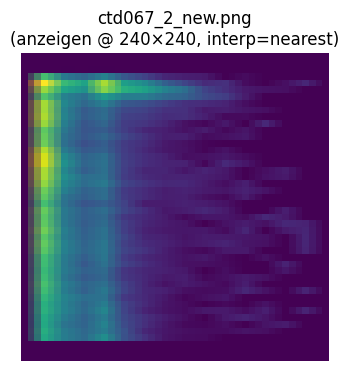

Starting Heatmap CNN Classification Pipeline
Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 2)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  6
Loading heatmap images...
Found 5619 PNG files in ../Data/heatmaps_05
Sample filenames: ['c_msm23_048.png', 'so287_23.png', 'ctd046_1_new.png', 'azomp013.png', 'dewex_leg2_47.png']
Sample extracted profile IDs: ['c_msm23_048', 'so287_23', 'ctd046_1_new', 'azomp013', 'dewex_leg2_47']
Available profile IDs from filenames: 5619
Profile IDs with train/test data: 5619
Profile IDs with cluster data:  5619
Files matching train/test IDs: 5619
Files matching cluster IDs: 5619
Files matching all data sources: 5619
Found 5619 profiles with complete dat

2026-01-05 01:35:04.738073: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-01-05 01:35:04.738453: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-01-05 01:35:04.738458: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
I0000 00:00:1767573304.738865 1762427 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1767573304.739242 1762427 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/100


2026-01-05 01:35:06.604683: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


99/99 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.1616 - loss: 3.9090 - val_accuracy: 0.1985 - val_loss: 2.2695 - learning_rate: 0.0010
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.1975 - loss: 3.4780 - val_accuracy: 0.2154 - val_loss: 2.1699 - learning_rate: 0.0010
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.2527 - loss: 3.0985 - val_accuracy: 0.2690 - val_loss: 2.2043 - learning_rate: 0.0010
Epoch 4/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.2962 - loss: 2.7111 - val_accuracy: 0.3528 - val_loss: 1.9438 - learning_rate: 0.0010
Epoch 5/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.3375 - loss: 2.4964 - val_accuracy: 0.3631 - val_loss: 1.7449 - learning_rate: 0.0010
Epoch 6/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.3654 - loss: 2.2213 - val_accuracy: 0.4581 - val_loss: 1.5591 - learning_rate: 0.0010
Epoch 7/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.3848 - loss: 2.0792 - val_accurac

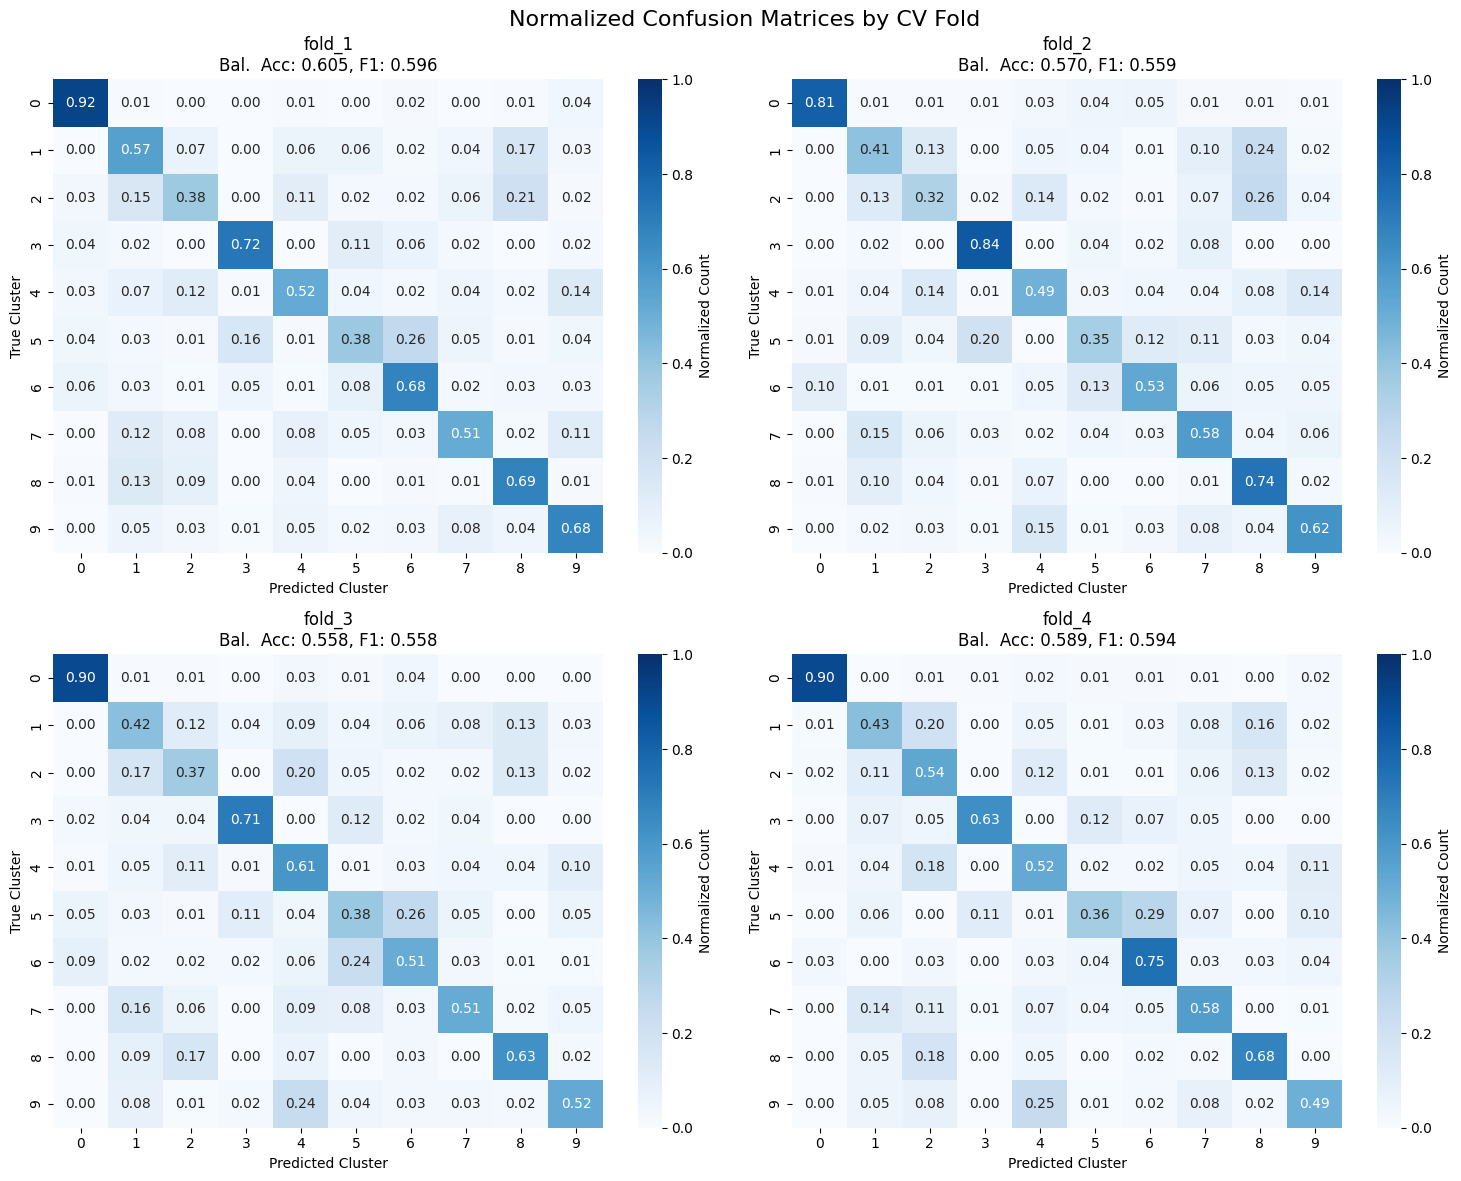


OVERALL CV SUMMARY
Heatmap Dir: ../Data/heatmaps_05
Heatmap Params:

--- Content of __params_for_heatmaps_05.txt ---

size: 48^2 px
crop: 1px
color theme: None
interpolation: bilinear
gamma: 0.8
gaussion strength: 0.1

Don't forget to reset model for next training!
Mean Balanced Accuracy: 0.580 ± 0.018
Mean Macro F1: 0.577 ± 0.018

Pipeline completed successfully!
../Data/heatmaps_06


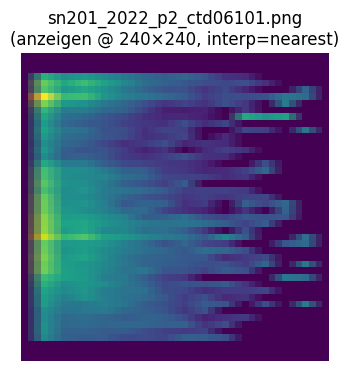

Starting Heatmap CNN Classification Pipeline
Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 2)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  6
Loading heatmap images...
Found 5619 PNG files in ../Data/heatmaps_05
Sample filenames: ['c_msm23_048.png', 'so287_23.png', 'ctd046_1_new.png', 'azomp013.png', 'dewex_leg2_47.png']
Sample extracted profile IDs: ['c_msm23_048', 'so287_23', 'ctd046_1_new', 'azomp013', 'dewex_leg2_47']
Available profile IDs from filenames: 5619
Profile IDs with train/test data: 5619
Profile IDs with cluster data:  5619
Files matching train/test IDs: 5619
Files matching cluster IDs: 5619
Files matching all data sources: 5619
Found 5619 profiles with complete dat

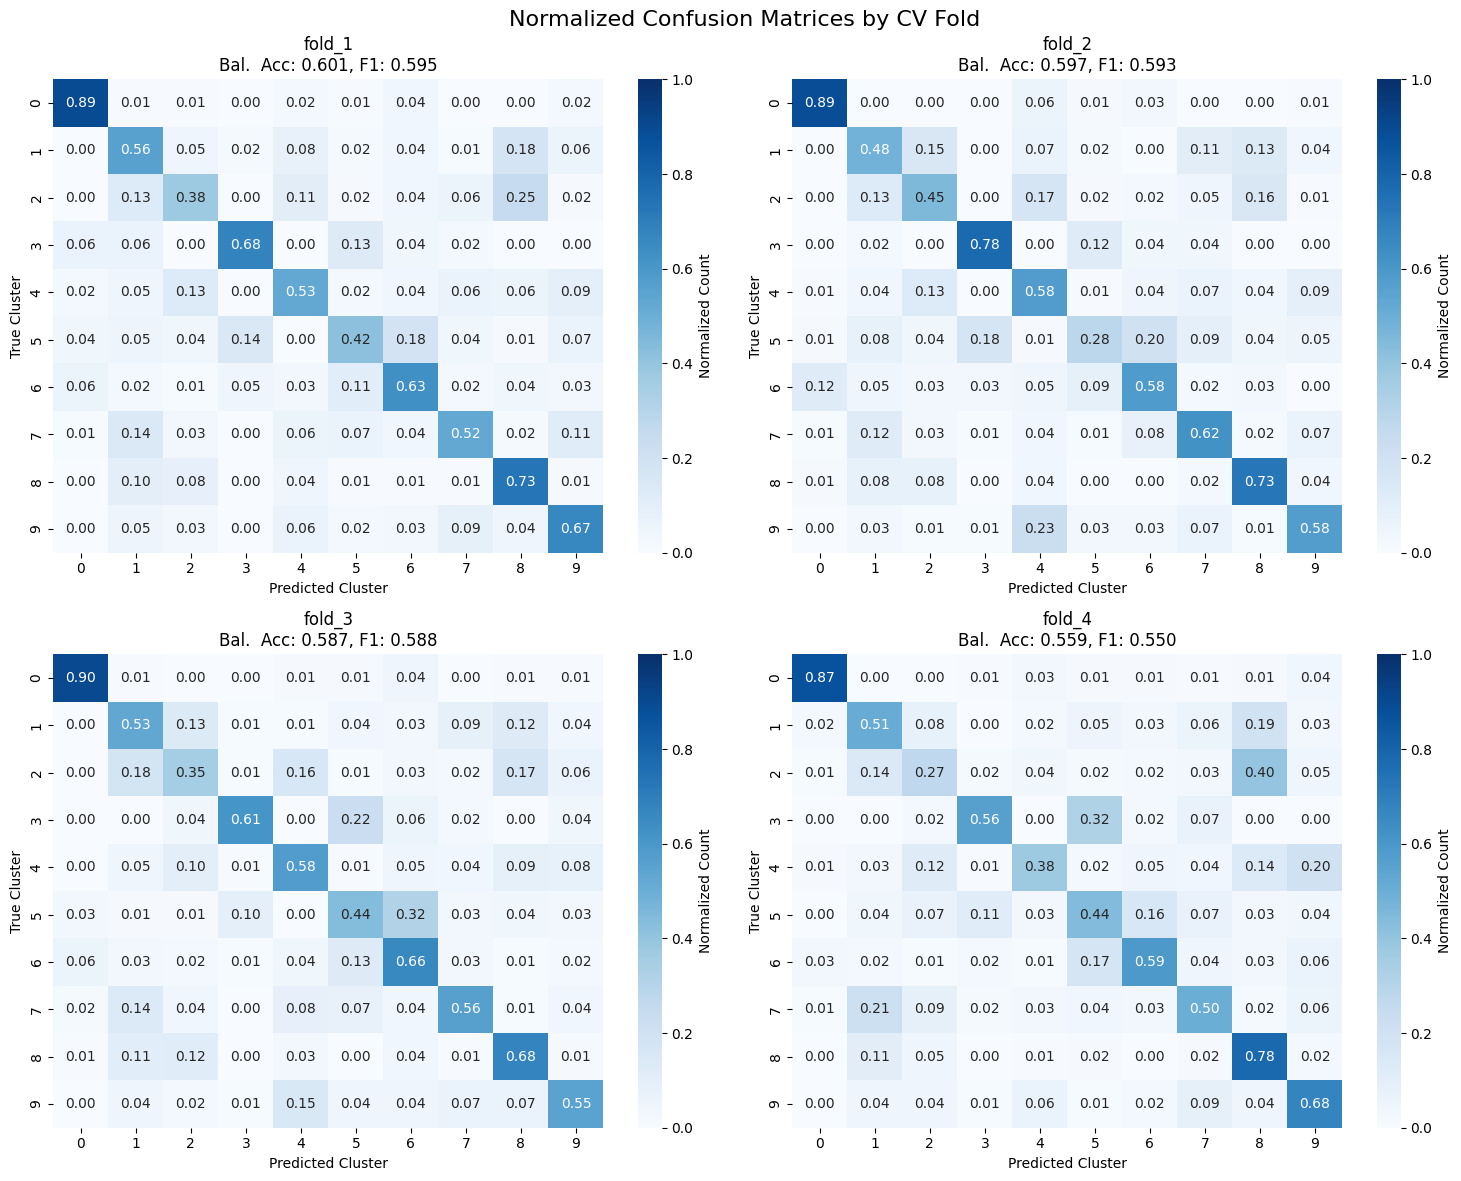


OVERALL CV SUMMARY
Heatmap Dir: ../Data/heatmaps_05
Heatmap Params:

--- Content of __params_for_heatmaps_05.txt ---

size: 48^2 px
crop: 1px
color theme: None
interpolation: bilinear
gamma: 0.8
gaussion strength: 0.1

Don't forget to reset model for next training!
Mean Balanced Accuracy: 0.586 ± 0.016
Mean Macro F1: 0.581 ± 0.018

Pipeline completed successfully!
../Data/heatmaps_07


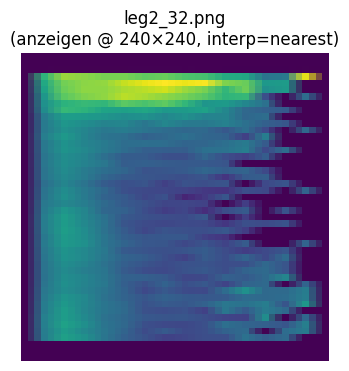

Starting Heatmap CNN Classification Pipeline
Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 2)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  6
Loading heatmap images...
Found 5619 PNG files in ../Data/heatmaps_05
Sample filenames: ['c_msm23_048.png', 'so287_23.png', 'ctd046_1_new.png', 'azomp013.png', 'dewex_leg2_47.png']
Sample extracted profile IDs: ['c_msm23_048', 'so287_23', 'ctd046_1_new', 'azomp013', 'dewex_leg2_47']
Available profile IDs from filenames: 5619
Profile IDs with train/test data: 5619
Profile IDs with cluster data:  5619
Files matching train/test IDs: 5619
Files matching cluster IDs: 5619
Files matching all data sources: 5619
Found 5619 profiles with complete dat

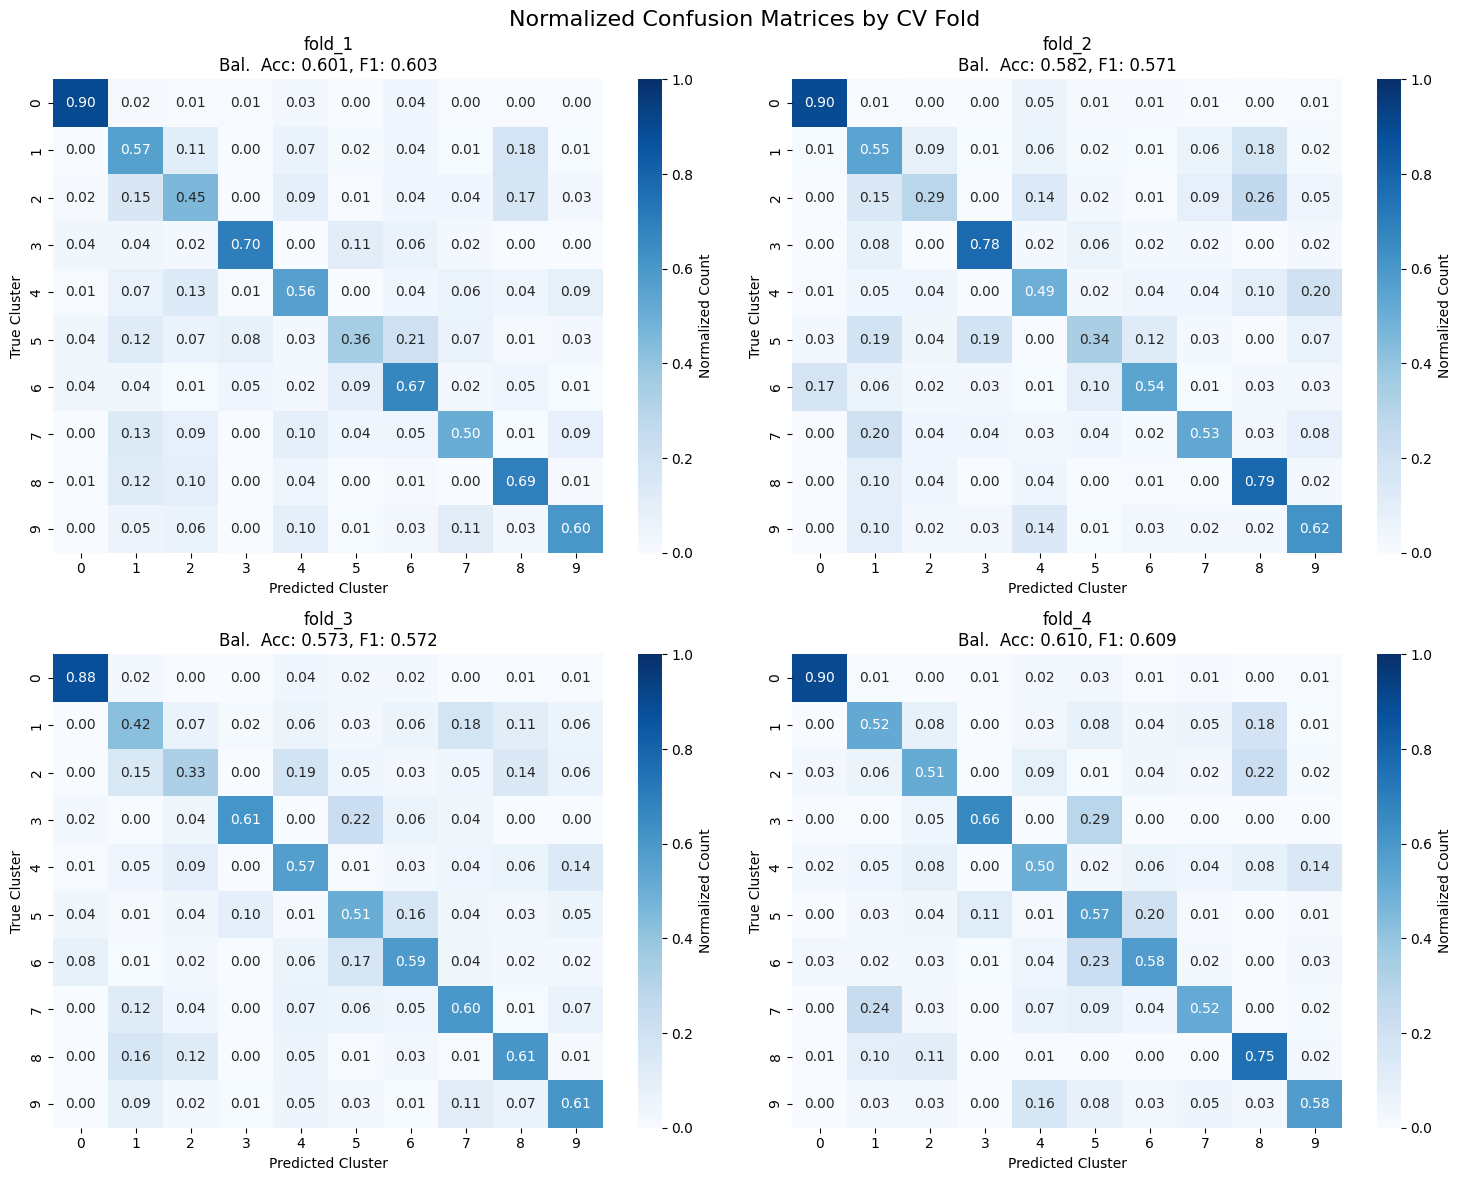


OVERALL CV SUMMARY
Heatmap Dir: ../Data/heatmaps_05
Heatmap Params:

--- Content of __params_for_heatmaps_05.txt ---

size: 48^2 px
crop: 1px
color theme: None
interpolation: bilinear
gamma: 0.8
gaussion strength: 0.1

Don't forget to reset model for next training!
Mean Balanced Accuracy: 0.591 ± 0.015
Mean Macro F1: 0.589 ± 0.017

Pipeline completed successfully!
../Data/heatmaps_25


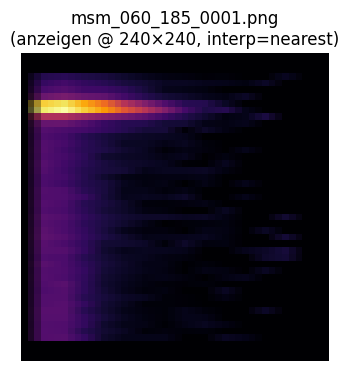

Starting Heatmap CNN Classification Pipeline
Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 2)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  6
Loading heatmap images...
Found 5619 PNG files in ../Data/heatmaps_05
Sample filenames: ['c_msm23_048.png', 'so287_23.png', 'ctd046_1_new.png', 'azomp013.png', 'dewex_leg2_47.png']
Sample extracted profile IDs: ['c_msm23_048', 'so287_23', 'ctd046_1_new', 'azomp013', 'dewex_leg2_47']
Available profile IDs from filenames: 5619
Profile IDs with train/test data: 5619
Profile IDs with cluster data:  5619
Files matching train/test IDs: 5619
Files matching cluster IDs: 5619
Files matching all data sources: 5619
Found 5619 profiles with complete dat

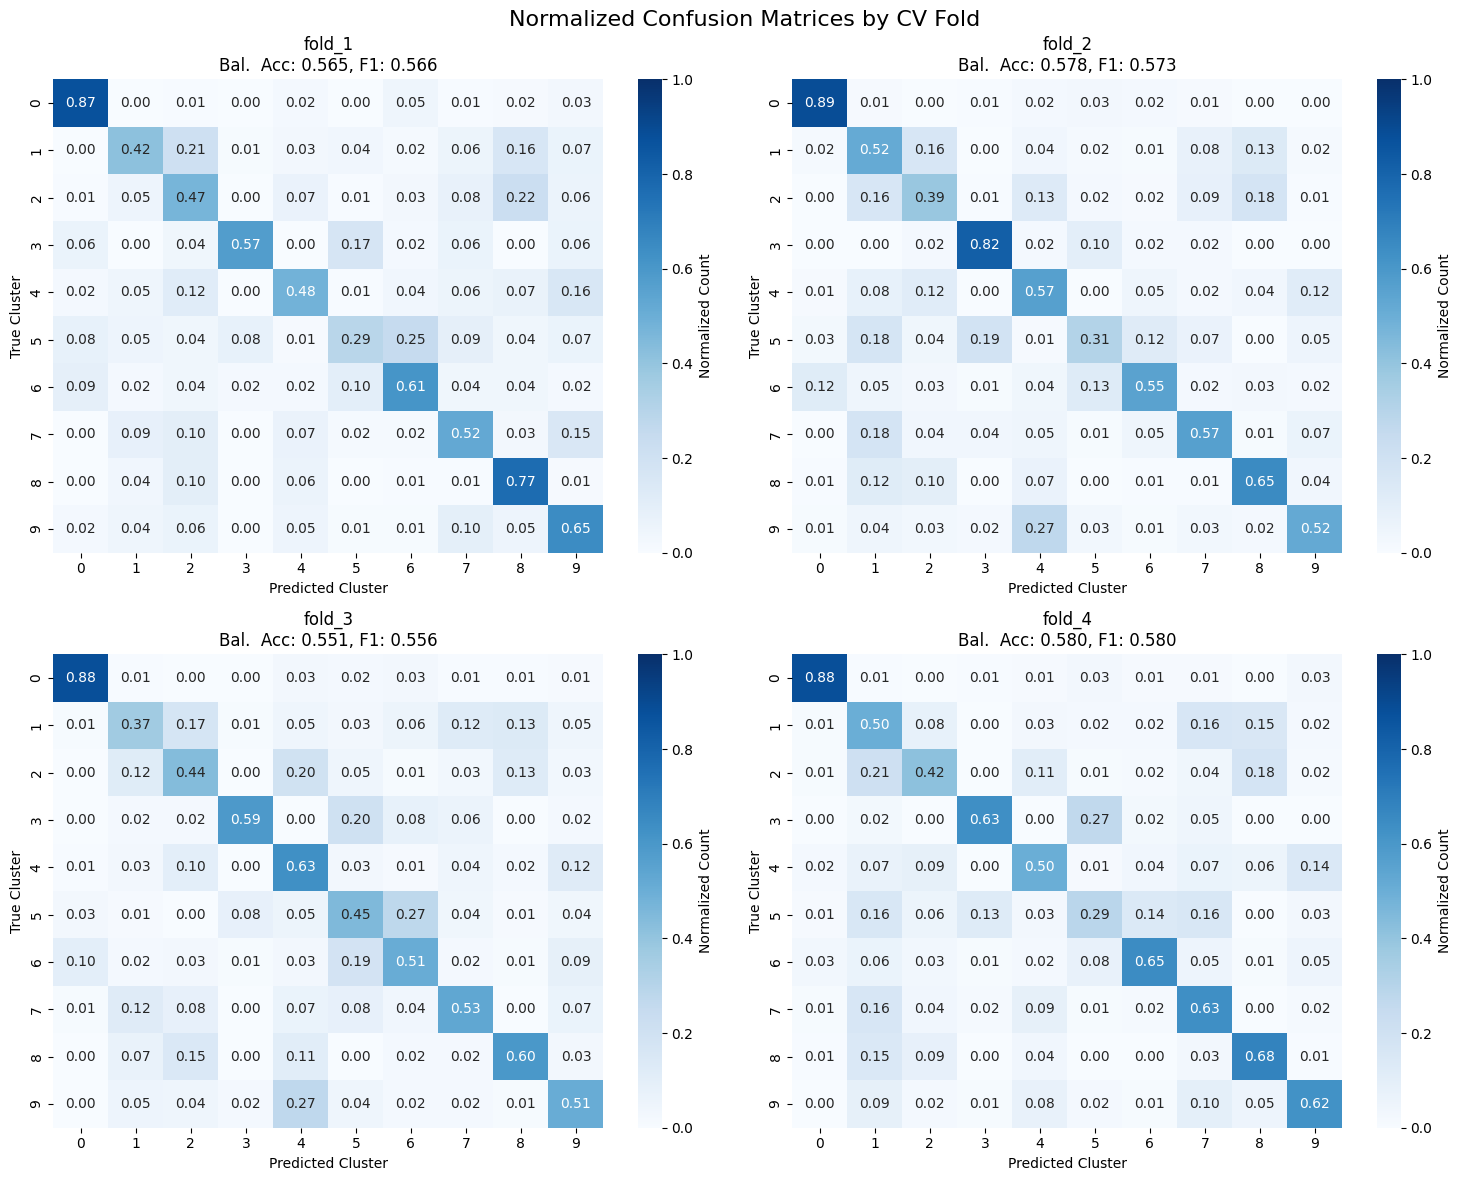


OVERALL CV SUMMARY
Heatmap Dir: ../Data/heatmaps_05
Heatmap Params:

--- Content of __params_for_heatmaps_05.txt ---

size: 48^2 px
crop: 1px
color theme: None
interpolation: bilinear
gamma: 0.8
gaussion strength: 0.1

Don't forget to reset model for next training!
Mean Balanced Accuracy: 0.569 ± 0.012
Mean Macro F1: 0.569 ± 0.009

Pipeline completed successfully!
../Data/heatmaps_26


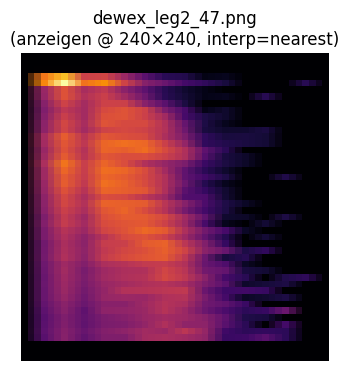

Starting Heatmap CNN Classification Pipeline
Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 2)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  6
Loading heatmap images...
Found 5619 PNG files in ../Data/heatmaps_05
Sample filenames: ['c_msm23_048.png', 'so287_23.png', 'ctd046_1_new.png', 'azomp013.png', 'dewex_leg2_47.png']
Sample extracted profile IDs: ['c_msm23_048', 'so287_23', 'ctd046_1_new', 'azomp013', 'dewex_leg2_47']
Available profile IDs from filenames: 5619
Profile IDs with train/test data: 5619
Profile IDs with cluster data:  5619
Files matching train/test IDs: 5619
Files matching cluster IDs: 5619
Files matching all data sources: 5619
Found 5619 profiles with complete dat

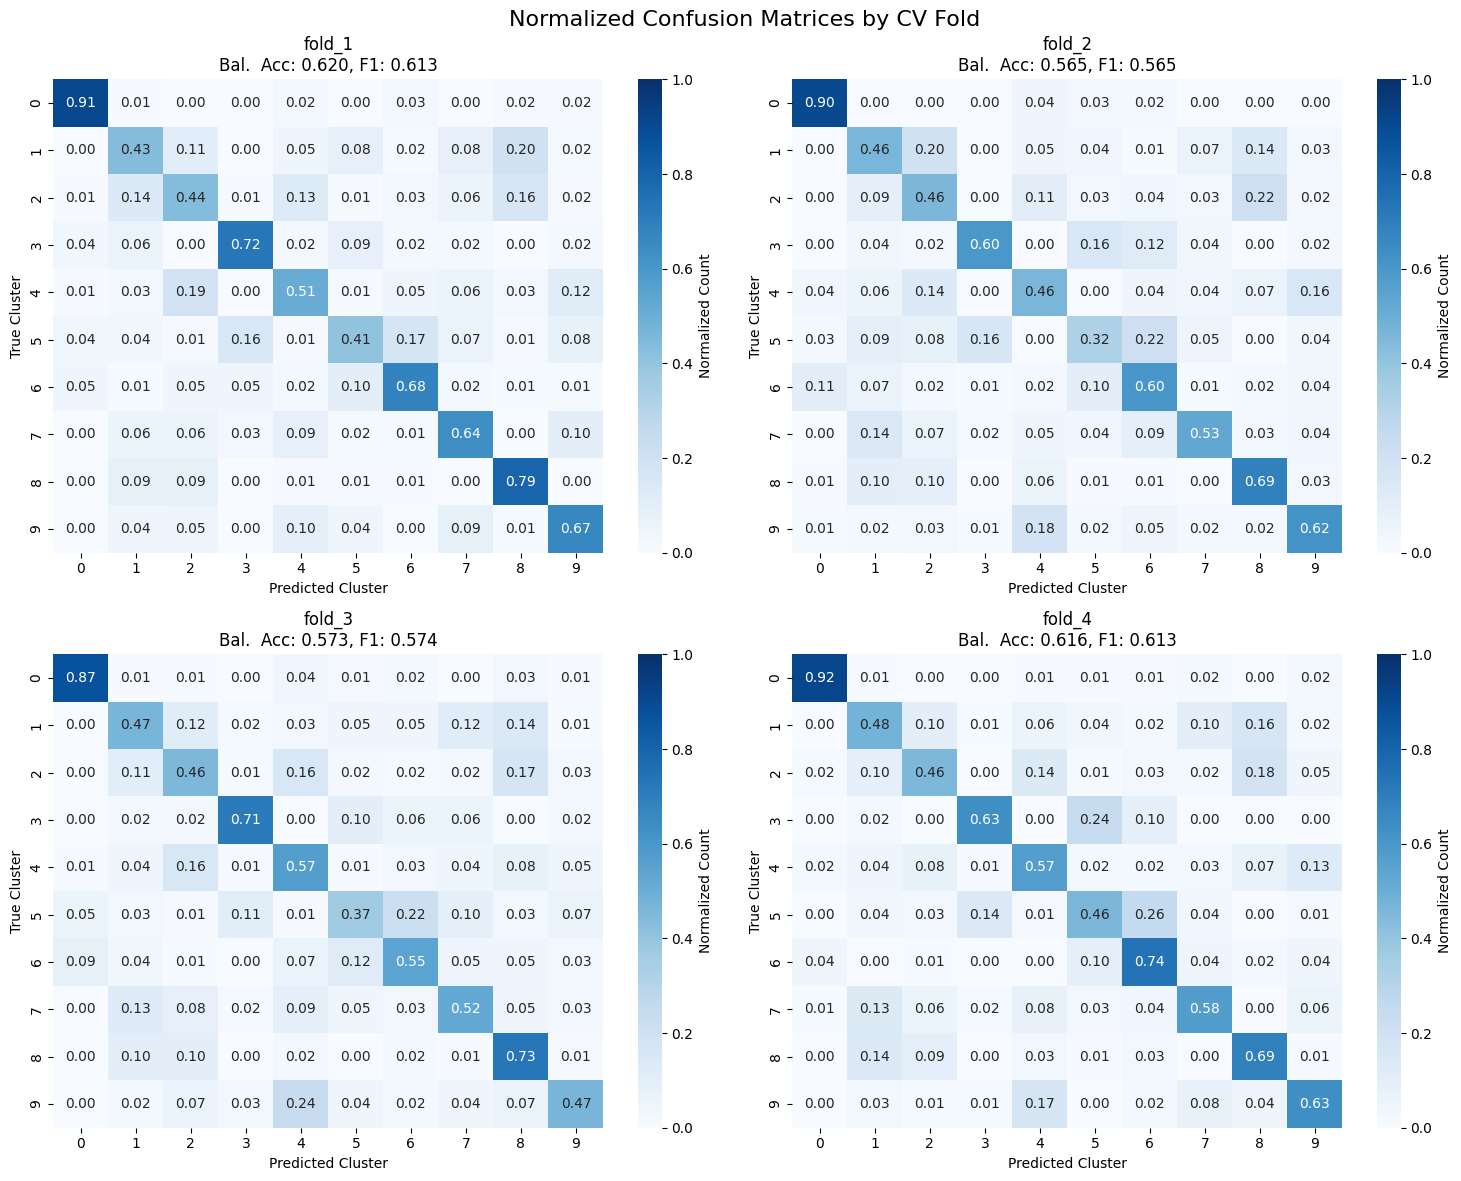


OVERALL CV SUMMARY
Heatmap Dir: ../Data/heatmaps_05
Heatmap Params:

--- Content of __params_for_heatmaps_05.txt ---

size: 48^2 px
crop: 1px
color theme: None
interpolation: bilinear
gamma: 0.8
gaussion strength: 0.1

Don't forget to reset model for next training!
Mean Balanced Accuracy: 0.593 ± 0.025
Mean Macro F1: 0.591 ± 0.022

Pipeline completed successfully!
../Data/heatmaps_27


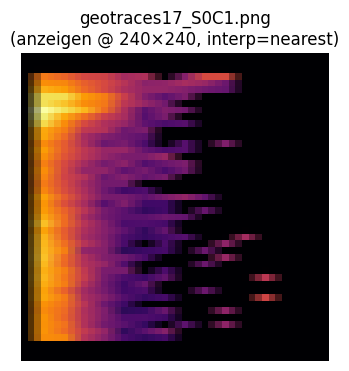

Starting Heatmap CNN Classification Pipeline
Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 2)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  6
Loading heatmap images...
Found 5619 PNG files in ../Data/heatmaps_05
Sample filenames: ['c_msm23_048.png', 'so287_23.png', 'ctd046_1_new.png', 'azomp013.png', 'dewex_leg2_47.png']
Sample extracted profile IDs: ['c_msm23_048', 'so287_23', 'ctd046_1_new', 'azomp013', 'dewex_leg2_47']
Available profile IDs from filenames: 5619
Profile IDs with train/test data: 5619
Profile IDs with cluster data:  5619
Files matching train/test IDs: 5619
Files matching cluster IDs: 5619
Files matching all data sources: 5619
Found 5619 profiles with complete dat

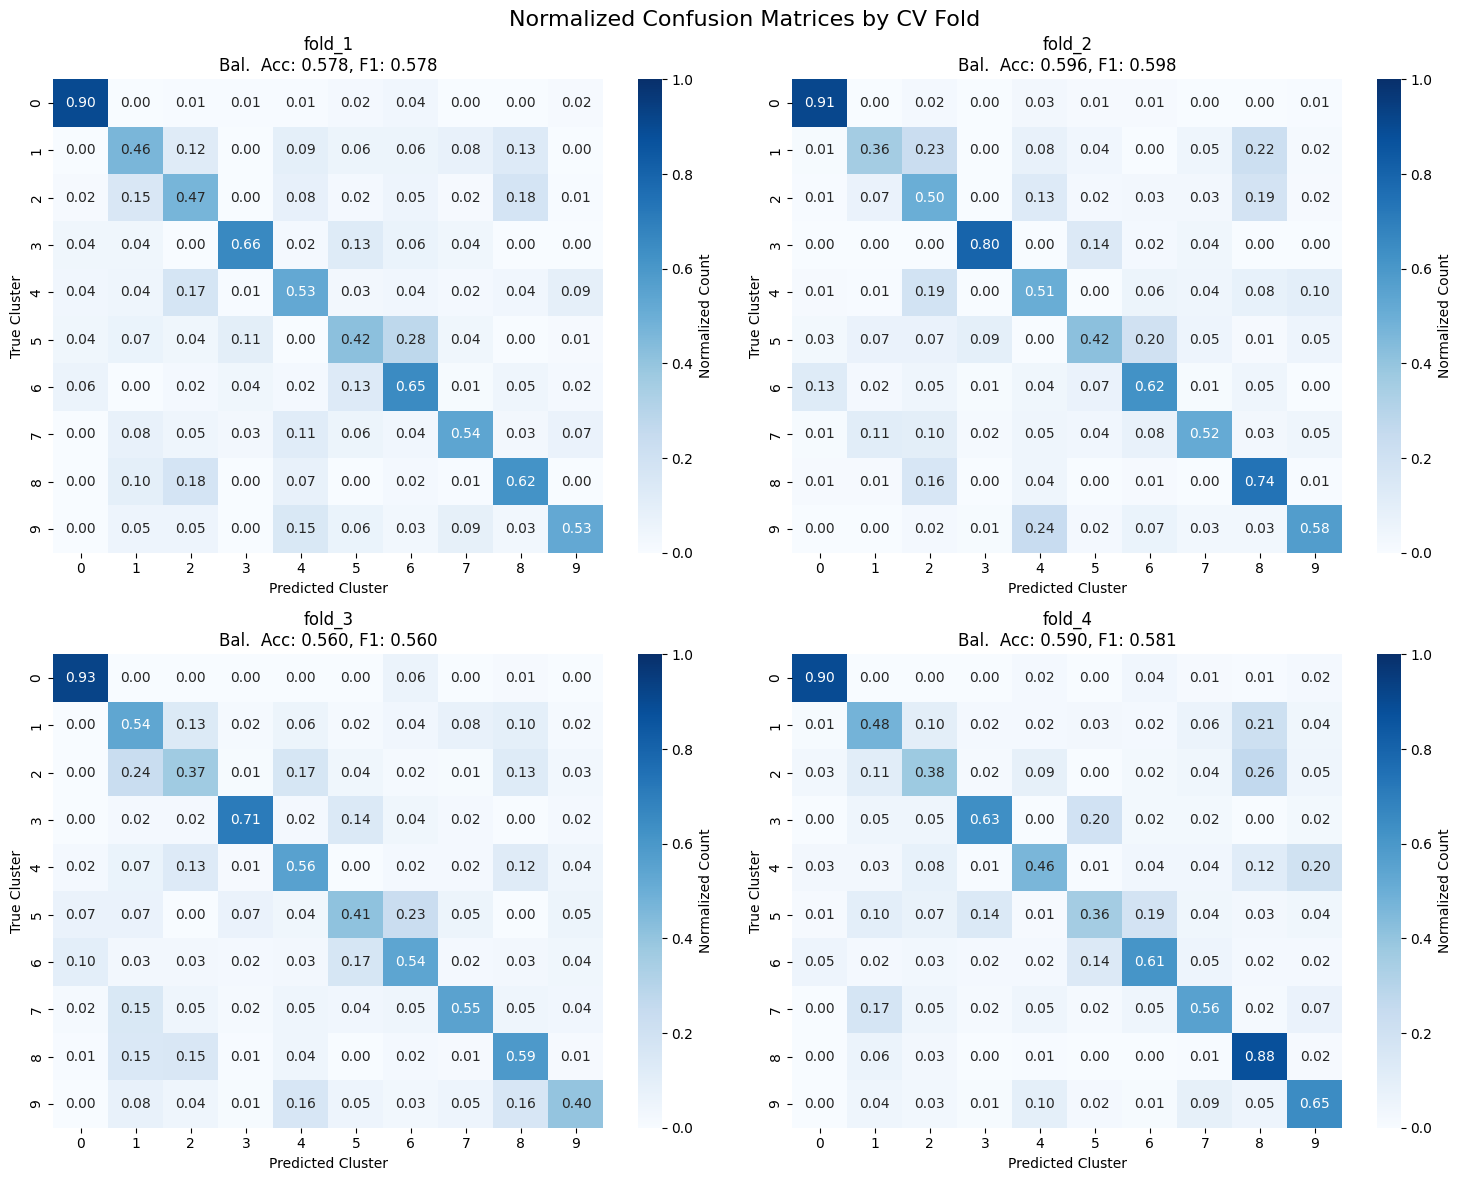


OVERALL CV SUMMARY
Heatmap Dir: ../Data/heatmaps_05
Heatmap Params:

--- Content of __params_for_heatmaps_05.txt ---

size: 48^2 px
crop: 1px
color theme: None
interpolation: bilinear
gamma: 0.8
gaussion strength: 0.1

Don't forget to reset model for next training!
Mean Balanced Accuracy: 0.581 ± 0.014
Mean Macro F1: 0.579 ± 0.013

Pipeline completed successfully!


In [19]:
"""
matches = list(Path(HEATMAP_DIR).name.glob("heatmaps_"))
for each in heatmap_option:
    print(f"\n" + f”="*50)
    print(f"{HEATMAP_DIR}")
    classifier = HeatmapCNNClassifier()
    classifier.run_full_pipeline()

"""

#########

import re
import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

HEATMAP_ROOT = Path("../Data/heatmaps").parent

def natural_sort_key(path: Path):
    return [int(part) if part.isdigit() else part.lower()
            for part in re.split(r"(\d+)", path.name)]

def pick_random_heatmap_image(dir_path: Path) -> Path | None:
    exts = ("*.png", "*.jpg", "*.jpeg", "*.webp")
    files = []
    for ext in exts:
        files.extend(dir_path.glob(ext))
    return random.choice(files) if files else None

def show_scaled_image(img_path: Path, out_px: int = 240, interpolation: str = "nearest"):
    img = mpimg.imread(img_path)  # (H,W) oder (H,W,C)
    plt.figure(figsize=(4, 4))
    plt.imshow(img, interpolation=interpolation)
    # Matplotlib skaliert beim Rendern automatisch auf die Figure.
    # Wenn du "wirklich" auf 240x240 resizen willst: siehe Alternative unten.
    plt.title(f"{img_path.name}\n(anzeigen @ {out_px}×{out_px}, interp={interpolation})")
    plt.axis("off")
    plt.show()

matches_dir = sorted(list(HEATMAP_ROOT.glob("heatmaps_*")), key=natural_sort_key)

print("\n" + "=" * 50)
for heatmap_dir in matches_dir:
    if not heatmap_dir.is_dir():
        continue

    print(heatmap_dir)

    # 1) Random-Beispielbild ausgeben
    sample = pick_random_heatmap_image(heatmap_dir)
    if sample is None:
        print("  (keine Bilddatei gefunden: png/jpg/jpeg/webp)")
    else:
        show_scaled_image(sample, out_px=240, interpolation="nearest")  # oder "bilinear"

    # 2) Pipeline laufen lassen
    classifier = HeatmapCNNClassifier()
    classifier.run_full_pipeline()


# import re
# from pathlib import Path

# HEATMAP_DIR = Path("../Data/heatmaps").parent

# def natural_sort_key(path: Path):
#     return [
#         int(part) if part.isdigit() else part.lower()
#         for part in re.split(r"(\d+)", path.name)
#     ]

# matches_dir = list(HEATMAP_DIR.glob("heatmaps_*"))
# matches_dir = sorted(matches_dir, key=natural_sort_key)

# for heatmap_dir in matches_dir:
#     if not heatmap_dir.is_dir():
#         continue
#     print(heatmap_dir)

# print("\n"+"="*50)
# for heatmap_dir in matches_dir:
#     if not heatmap_dir.is_dir():
#         continue
    
#     HEATMAP_DIR = heatmap_dir
#     print(heatmap_dir)

#     classifier = HeatmapCNNClassifier()
#     classifier.run_full_pipeline()

### Fit model on full training data (once tuning is complete) and evaluate on test data

### SHAP analysis

## Second CNN: hierarchal model

## Hyperparameter Tuning

[Discuss any hyperparameter tuning methods you've applied, such as Grid Search or Random Search, and the rationale behind them.]


In [15]:
# Implement hyperparameter tuning
# Example using GridSearchCV with a DecisionTreeClassifier
# param_grid = {'max_depth': [2, 4, 6, 8]}
# grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
# grid_search.fit(X_train, y_train)


## Implementation

[Implement the final model(s) you've selected based on the above steps.]


In [16]:
# Implement the final model(s)
# Example: model = YourChosenModel(best_hyperparameters)
# model.fit(X_train, y_train)


## Evaluation Metrics

[Clearly specify which metrics you'll use to evaluate the model performance, and why you've chosen these metrics.]


In [17]:
# Evaluate the model using your chosen metrics
# Example for classification
# y_pred = model.predict(X_test)
# print(classification_report(y_test, y_pred))

# Example for regression
# mse = mean_squared_error(y_test, y_pred)

# Your evaluation code here


## Comparative Analysis

[Compare the performance of your model(s) against the baseline model. Discuss any improvements or setbacks and the reasons behind them.]


In [18]:
# Comparative Analysis code (if applicable)
# Example: comparing accuracy of the baseline model and the new model
# print(f"Baseline Model Accuracy: {baseline_accuracy}, New Model Accuracy: {new_model_accuracy}")
